# Resource Usage Analysis

This notebook analyzes computational resource requirements (CPU time, memory, wall-clock time) for all tools on both real (IMG/VR4 subsampled) and simulated datasets. Results are exported to manuscript directories for publication.



**Key outputs:**- Dataset size: Total nucleotides in Mbp (megabase pairs)

- Main text figure: CPU time vs dataset size (real vs simulated, side-by-side)- Memory: Peak RSS in GB

- Supplementary figures: Same with minimap2 included, plus detailed breakdowns- Wall Time: Elapsed wall-clock time in hours

- Tables: Detailed resource usage for all completed jobs (TSV format)- CPU Time: Total CPU time in hours (TotalCPU from SLURM, already accounts for number of cores)

**Note on units:**

## Part 1: Real Data Analysis (IMG/VR4 Subsampled Datasets)

Analysis of resource usage on real IMG/VR4 datasets at various subsample fractions (0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 1.0) with iPHoP spacers. All tools were run on identical hardware (dual AMD EPYC 7543, 64 cores, 512 GB RAM) via SLURM. Max distance thresholds vary by fraction size and tool capabilities (see Prepare_all_jobs.ipynb for details).


**Reminder** - for blastn fraction_1, resource tracking for the 64 thread job was only done until the 1689771th spacer out of 3826979 total spacers.


**Implementation**: The code below automatically extrapolates blastn's fraction_1 runtime by multiplying the observed runtime by 3826979/1689771 ≈ 2.266 to estimate the total runtime. This is valid because blastn scales linearly with the number of input spacers.


<!-- :>MGYG000018353:MGYG000018353_21:1:pilercr14 -->


In [1]:
import os
import json
from pathlib import Path


os.chdir('/clusterfs/jgi/scratch/science/metagen/neri/code/blits/spacer_bench/')
from bench import *
from bench.utils.functions import *
from bench.utils.pyseff import *
import polars as pl
pl.Config(tbl_rows=110)

import numpy as np
main_fig_dir = Path('draft/main/figures/resource_usage')
supp_fig_dir = Path('draft/supp/figures/resource_usage')
main_table_dir = Path('draft/main/figures/tables')
supp_table_dir = Path('draft/supp/figures/tables')
results_real_plots = Path('results/real_data/plots')
results_sim_plots = Path('results/simulated/plots')
for d in [main_fig_dir, supp_fig_dir, main_table_dir, supp_table_dir, results_real_plots, results_sim_plots]:
    d.mkdir(parents=True, exist_ok=True)


base_dir = '/clusterfs/jgi/scratch/science/metagen/neri/code/blits/spacer_bench/results/real_data/subsamples/fraction_0.001/'
threads = 12
tools_versions = pl.read_csv('tool_configs/tool_versions.csv')
tool_configs = load_tool_configs(base_dir)
tool_names = list(tool_configs.keys())

from lets_plot import *
import json


with open("notebooks/tool_styles.json", "r") as f:
    tool_styles = json.load(f)


LetsPlot.setup_html()


tool_colors = {tool: styles['color'] for tool, styles in tool_styles.items()}
tool_shapes = {tool: styles['letsplot_shape_num'] for tool, styles in tool_styles.items()}


In [2]:
sacct_df = pyseff(remove_cancelled=False, remove_failed=False, calculate_cpu_efficiency=False, calculate_memory_efficiency=False)
sacct_df = sacct_df.with_columns(
    pl.col('JobName').str.replace_all('_long', '').str.replace_all('mmseqs', 'mmseqs2')
)
sacct_df = sacct_df.filter(~pl.col('JobName').str.contains_any(['damn', 'biofaster'])).filter(
    pl.col('JobName').str.contains_any(tool_names)
)
# sacct_df


Get all jobids that are actually needed


In [3]:
import glob
log_files = glob.glob('results/real_data/subsamples/fraction_*/slurm_logs/*.out')
log_files_df = pl.DataFrame({'log_file': log_files}).with_columns(
    pl.col('log_file').str.extract(r'-(\d+)\.out').alias('BaseJobID'),
    pl.col('log_file').str.extract(r'fraction_([\d.]+)').alias('fraction'),
    pl.col('log_file').str.extract(r'slurm_logs/(.+)-\d+\.out').str.replace_all('_long', '').str.replace_all('mmseqs', 'mmseqs2').alias('tool_name')
)
log_files_df = log_files_df.join(sacct_df, on='BaseJobID', how='inner')
# log_files_df


In [4]:
# Get contig counts and total sizes for each fraction
fraction_dirs = glob.glob('results/real_data/subsamples/fraction_*')
contig_counts = []


for fdir in sorted(fraction_dirs):
    fraction = fdir.split('fraction_')[-1]
    metadata_file = os.path.join(fdir, 'subsampled_data/subsampled_metadata.tsv')
    if os.path.exists(metadata_file):
        metadata_df = pl.read_csv(metadata_file, separator='\t')
        num_contigs = len(metadata_df)
        total_size_bp = metadata_df['length'].sum()
        contig_counts.append({
            'fraction': fraction,
            'fraction_float': float(fraction),
            'num_contigs': num_contigs,
            'total_size_bp': total_size_bp,
            'total_size_Mbp': total_size_bp / 1_000_000,
        })


contig_counts_df = pl.DataFrame(contig_counts).sort('fraction_float')
print('Contig counts and sizes by fraction:')
print(contig_counts_df)


Contig counts and sizes by fraction:
shape: (7, 5)
┌──────────┬────────────────┬─────────────┬───────────────┬────────────────┐
│ fraction ┆ fraction_float ┆ num_contigs ┆ total_size_bp ┆ total_size_Mbp │
│ ---      ┆ ---            ┆ ---         ┆ ---           ┆ ---            │
│ str      ┆ f64            ┆ i64         ┆ i64           ┆ f64            │
╞══════════╪════════════════╪═════════════╪═══════════════╪════════════════╡
│ 0.0005   ┆ 0.0005         ┆ 279         ┆ 7036591       ┆ 7.036591       │
│ 0.001    ┆ 0.001          ┆ 421         ┆ 9745671       ┆ 9.745671       │
│ 0.005    ┆ 0.005          ┆ 2107        ┆ 57059412      ┆ 57.059412      │
│ 0.01     ┆ 0.01           ┆ 4214        ┆ 123668270     ┆ 123.66827      │
│ 0.05     ┆ 0.05           ┆ 21071       ┆ 715073062     ┆ 715.073062     │
│ 0.1      ┆ 0.1            ┆ 42143       ┆ 1504536616    ┆ 1504.536616    │
│ 1        ┆ 1.0            ┆ 421431      ┆ 18870643188   ┆ 18870.643188   │
└──────────┴─────────────

In [5]:
# Get spacer counts and total size (same for all fractions)
spacer_file = 'imgvr4_data/spacers/iphop_filtered_spacers.fna'
spacer_df = pl.DataFrame(read_fasta_needletail(spacer_file), schema={'seqid': pl.Utf8, 'seq': pl.Utf8})
spacer_df = spacer_df.with_columns(pl.col('seq').str.len_chars().alias('length')).drop('seq')
num_spacers = spacer_df.height
total_spacer_bp = spacer_df['length'].sum()
total_spacer_Mbp = total_spacer_bp / 1_000_000
print('Spacer dataset (constant across all fractions):')
print(f'  Number of spacers: {num_spacers:,}')
print(f'  Total length: {total_spacer_bp:,} bp ({total_spacer_Mbp:.2f} Mbp)')


Spacer dataset (constant across all fractions):
  Number of spacers: 3,826,979
  Total length: 129,494,053 bp (129.49 Mbp)


In [6]:
# Inspect Elapsed vs TotalCPU to confirm units
sample_check = log_files_df.select([
    "tool_name", "fraction", "AllocCPUS", "Elapsed_Seconds", "TotalCPU_Seconds"
]).head(20)


# print("Sample of timing data:")
print(sample_check)


cpu_check = log_files_df.with_columns([
    pl.col("log_file").str.contains("_long").alias("is_long")
]).group_by(["tool_name", "is_long"]).agg([
    pl.col("AllocCPUS").unique().alias("CPU_values"),
    pl.len().alias("count")
]).sort("tool_name")


# print("\nCPU allocation by tool and retry status:")
# print(cpu_check)


shape: (20, 5)
┌──────────────────────┬──────────┬───────────┬─────────────────┬──────────────────┐
│ tool_name            ┆ fraction ┆ AllocCPUS ┆ Elapsed_Seconds ┆ TotalCPU_Seconds │
│ ---                  ┆ ---      ┆ ---       ┆ ---             ┆ ---              │
│ str                  ┆ str      ┆ i64       ┆ u32             ┆ u32              │
╞══════════════════════╪══════════╪═══════════╪═════════════════╪══════════════════╡
│ mmseqs2              ┆ 1        ┆ 38        ┆ 2631            ┆ 19320            │
│ mmseqs2              ┆ 0.1      ┆ 38        ┆ 481             ┆ 0                │
│ blastn               ┆ 0.001    ┆ 38        ┆ 1971            ┆ 32472            │
│ mmseqs2              ┆ 0.001    ┆ 38        ┆ 237             ┆ 0                │
│ minimap2             ┆ 0.005    ┆ 38        ┆ 528             ┆ 0                │
│ mummer4              ┆ 0.0005   ┆ 38        ┆ 24              ┆ 0                │
│ bowtie2              ┆ 0.05     ┆ 38        ┆ 52

In [7]:
# max_distance settings per tool/fraction (for plotting and reporting)
def get_max_distance(tool_name, fraction_float):
    if fraction_float in [0.0005, 0.001, 0.005, 0.01]:
        configured_max_dist = 5
    elif fraction_float in [0.05, 0.1, 1.0]:
        configured_max_dist = 3
    else:
        configured_max_dist = None


    if tool_name in ['indelfree_bruteforce', 'indelfree_indexed', 'sassy']:
        return str(configured_max_dist) if configured_max_dist is not None else "N/A"
    if tool_name == 'bowtie1':
        return "3"
    if tool_name == 'blastn':
        return "perc_id=84%"
    if tool_name == 'mmseqs2':
        return "min-seq-id=85%"
    return "N/A"


log_files_df = log_files_df.with_columns([
    pl.struct(["tool_name", "fraction"]).map_elements(
        lambda x: get_max_distance(x["tool_name"], x["fraction"]),
        return_dtype=pl.Utf8
    ).alias("max_distance_setting")
])


print("Max distance settings by tool and fraction:")
max_dist_summary = log_files_df.group_by(["tool_name", "fraction", "max_distance_setting"]).agg([
    pl.len().alias("count")
]).sort(["tool_name", "fraction"])
print(max_dist_summary)


Max distance settings by tool and fraction:
shape: (71, 4)
┌──────────────────────┬──────────┬──────────────────────┬───────┐
│ tool_name            ┆ fraction ┆ max_distance_setting ┆ count │
│ ---                  ┆ ---      ┆ ---                  ┆ ---   │
│ str                  ┆ str      ┆ str                  ┆ u64   │
╞══════════════════════╪══════════╪══════════════════════╪═══════╡
│ blastn               ┆ 0.0005   ┆ perc_id=84%          ┆ 2     │
│ blastn               ┆ 0.001    ┆ perc_id=84%          ┆ 2     │
│ blastn               ┆ 0.005    ┆ perc_id=84%          ┆ 2     │
│ blastn               ┆ 0.01     ┆ perc_id=84%          ┆ 1     │
│ blastn               ┆ 0.05     ┆ perc_id=84%          ┆ 1     │
│ blastn               ┆ 0.1      ┆ perc_id=84%          ┆ 1     │
│ blastn               ┆ 1        ┆ perc_id=84%          ┆ 1     │
│ bowtie1              ┆ 0.0005   ┆ 3                    ┆ 1     │
│ bowtie1              ┆ 0.001    ┆ 3                    ┆ 1     │
│ b

## Determine max_distance settings for each tool


Based on the Prepare_all_jobs.ipynb notebook:
- Smaller fractions (0.0005, 0.001, 0.005, 0.01): max_distance=5
- Larger fractions (0.05, 0.1): max_distance=3
- Full dataset (1): max_distance=3


Tool-specific notes:
- **bowtie1**: Always uses max_distance=3 (maximum it supports with -v flag)
- **blastn**: Uses perc_identity=84% and qcov_hsp_perc=80%, not a fixed edit distance
- **mmseqs2**: Uses min-seq-id=0.85, not a fixed edit distance
- **indelfree_bruteforce/indexed**: Use the configured max_distance (subs parameter)
- **sassy**: Uses the configured max_distance (-k parameter)


# Process jobs accounting for retries and fraction sizes


Key considerations:
- Multiple fraction sizes tested (0.001, 0.01, 0.1, etc.)
- Some jobs timed out and were resubmitted with "_long" suffix (may have different QOS/CPU allocation)
- For each tool-fraction combination, prefer completed jobs (prioritize _long if both exist)
- Track CPU allocations as they may differ between regular and _long jobs
- Report TIMEOUT only if all attempts failed for that tool-fraction


In [8]:
# Process log_files_df to handle regular and _long jobs
log_files_df = log_files_df.with_columns([
    pl.col("log_file").str.contains("_long").alias("is_long_retry"),
    pl.col("tool_name").alias("base_tool_name"),
    pl.col("fraction").cast(pl.Float64).alias("fraction_float")
])


log_files_df = log_files_df.with_columns([
    pl.col("State").list.get(0).alias("state_first"),
])


exclude_states = ['OUT_OF_MEMORY', 'CANCELLED', 'PREEMPTED', 'RUNNING']
log_files_df = log_files_df.with_columns([
    pl.col("state_first").is_in(exclude_states).alias("should_exclude"),
    pl.col("state_first").str.contains("TIMEOUT").fill_null(False).alias("is_timeout"),
    pl.col("state_first").str.contains("COMPLETED").fill_null(False).alias("is_completed"),
    pl.col("state_first").str.contains("FAILED").fill_null(False).alias("is_failed"),
])


job_selection = log_files_df.group_by(["base_tool_name", "fraction"]).agg([
    pl.all(),
])


def select_best_job(group_df):
    results = []
    for row in group_df.iter_rows(named=True):
        tool = row["base_tool_name"]
        fraction = row["fraction"]
        is_long = row["is_long_retry"]
        should_exclude = row["should_exclude"]
        is_completed = row["is_completed"]
        is_timeout = row["is_timeout"]
        is_failed = row["is_failed"]
        jobids = row["BaseJobID"]
        elapsed = row["Elapsed_Seconds"]
        total_cpu = row.get("TotalCPU_Seconds", elapsed)
        maxrss = row["MaxRSS_MB"]
        reqmem = row["ReqMem_MB"]
        alloccpus = row["AllocCPUS"]
        max_distance = row["max_distance_setting"]


        valid_indices = [i for i, excl in enumerate(should_exclude) if not excl]
        if not valid_indices:
            continue


        regular_idx = [i for i in valid_indices if not is_long[i]]
        long_idx = [i for i in valid_indices if is_long[i]]


        selected_idx = None
        status = None
        replaced_failed_job = False


        if long_idx:
            long_i = long_idx[0]
            if is_completed[long_i]:
                selected_idx = long_i
                status = "COMPLETED"
                if regular_idx and (is_timeout[regular_idx[0]] or is_failed[regular_idx[0]]):
                    replaced_failed_job = True
            elif is_timeout[long_i] or is_failed[long_i]:
                selected_idx = long_i
                status = "FAILED" if is_failed[long_i] else "TIMEOUT"


        if selected_idx is None and regular_idx:
            reg_i = regular_idx[0]
            if is_completed[reg_i]:
                selected_idx = reg_i
                status = "COMPLETED"
            elif is_timeout[reg_i] or is_failed[reg_i]:
                if not long_idx:
                    selected_idx = reg_i
                    status = "FAILED" if is_failed[reg_i] else "TIMEOUT"


        if selected_idx is not None:
            cpu_time_raw = total_cpu[selected_idx] if isinstance(total_cpu, list) else elapsed[selected_idx]
            elapsed_time = elapsed[selected_idx]
            cpu_time = elapsed_time if cpu_time_raw < 1 else cpu_time_raw


            blastn_extrapolation_factor = 3826979 / 1689771
            if tool == "blastn" and fraction == "1":
                cpu_time = cpu_time * blastn_extrapolation_factor
                elapsed_time = elapsed_time * blastn_extrapolation_factor
                if status in ["TIMEOUT", "FAILED"]:
                    status = "COMPLETED"


            results.append({
                "tool": tool,
                "fraction": fraction,
                "fraction_float": float(fraction) if fraction else 0,
                "BaseJobID": jobids[selected_idx],
                "status": status,
                "is_long_retry": is_long[selected_idx],
                "replaced_failed_job": replaced_failed_job,
                "Elapsed_Seconds": elapsed_time,
                "CPU_Time_Seconds": cpu_time,
                "MaxRSS_MB": maxrss[selected_idx],
                "ReqMem_MB": reqmem[selected_idx],
                "AllocCPUS": alloccpus[selected_idx],
                "Peak_Memory_Gb": maxrss[selected_idx] / 1024 if maxrss[selected_idx] else None,
                "CPU_Time_Hours": cpu_time / 3600,
                "Walltime_Hours": elapsed_time / 3600,
                "max_distance": max_distance[selected_idx] if isinstance(max_distance, list) else max_distance,
            })


    return pl.DataFrame(results) if results else pl.DataFrame()


processed_jobs = select_best_job(job_selection).sort(["tool", "fraction_float"])
print(f"Total jobs processed: {len(processed_jobs)}")
print(f"Unique tools: {processed_jobs['tool'].n_unique()}")
print(f"\nJobs using _long retry: {processed_jobs['is_long_retry'].sum()}")
print(f"Jobs that replaced failed attempts: {processed_jobs['replaced_failed_job'].sum()}")
# processed_jobs


Total jobs processed: 70
Unique tools: 11

Jobs using _long retry: 0
Jobs that replaced failed attempts: 0


In [9]:
# Keep completed jobs and add display/note columns
completed_jobs = processed_jobs.filter(pl.col("status") == "COMPLETED")


def get_tool_display_name(tool, max_dist):
    if tool in ['indelfree_bruteforce', 'indelfree_indexed', 'sassy'] and str(max_dist).isdigit():
        return f"{tool}_d{max_dist}"
    return tool


completed_jobs = completed_jobs.with_columns([
    pl.struct(["tool", "max_distance"]).map_elements(
        lambda x: get_tool_display_name(x["tool"], x["max_distance"]),
        return_dtype=pl.Utf8
    ).alias("tool_display")
])

status_summary = processed_jobs.group_by(["tool", "status"]).agg([
    pl.len().alias("count")
]).sort(["tool", "status"])
print("Job Status Summary:")
print(status_summary)
print(f"\nTotal completed jobs: {len(completed_jobs)}")
print(f"Total jobs with issues: {len(processed_jobs) - len(completed_jobs)}")


# Export completed job details
completed_jobs.write_parquet(main_table_dir / "resource_usage_real_completed_jobs.parquet")
completed_jobs.write_csv(main_table_dir / "resource_usage_real_completed_jobs.tsv", separator="\t")
completed_jobs.write_parquet(supp_table_dir / "resource_usage_real_completed_jobs.parquet")
completed_jobs.write_csv(supp_table_dir / "resource_usage_real_completed_jobs.tsv", separator="\t")
# completed_jobs


Job Status Summary:
shape: (13, 3)
┌──────────────────────┬───────────┬───────┐
│ tool                 ┆ status    ┆ count │
│ ---                  ┆ ---       ┆ ---   │
│ str                  ┆ str       ┆ u64   │
╞══════════════════════╪═══════════╪═══════╡
│ blastn               ┆ COMPLETED ┆ 6     │
│ bowtie1              ┆ COMPLETED ┆ 7     │
│ bowtie2              ┆ COMPLETED ┆ 7     │
│ indelfree_bruteforce ┆ COMPLETED ┆ 2     │
│ indelfree_bruteforce ┆ TIMEOUT   ┆ 2     │
│ indelfree_indexed    ┆ COMPLETED ┆ 6     │
│ indelfree_indexed    ┆ TIMEOUT   ┆ 1     │
│ minimap2             ┆ COMPLETED ┆ 7     │
│ mmseqs2              ┆ COMPLETED ┆ 7     │
│ mummer4              ┆ COMPLETED ┆ 7     │
│ sassy                ┆ COMPLETED ┆ 4     │
│ strobealign          ┆ COMPLETED ┆ 7     │
│ x_mapper             ┆ COMPLETED ┆ 7     │
└──────────────────────┴───────────┴───────┘

Total completed jobs: 67
Total jobs with issues: 3


In [10]:
print("Max Distance Settings Summary:")
max_dist_by_tool = completed_jobs.group_by(["tool", "tool_display", "max_distance"]).agg([
    pl.col("fraction").unique().sort().alias("fractions"),
    pl.len().alias("count")
]).sort("tool_display")
print(max_dist_by_tool)


Max Distance Settings Summary:
shape: (11, 5)
┌──────────────────────┬──────────────────────┬────────────────┬───────────────────────────────┬───────┐
│ tool                 ┆ tool_display         ┆ max_distance   ┆ fractions                     ┆ count │
│ ---                  ┆ ---                  ┆ ---            ┆ ---                           ┆ ---   │
│ str                  ┆ str                  ┆ str            ┆ list[str]                     ┆ u64   │
╞══════════════════════╪══════════════════════╪════════════════╪═══════════════════════════════╪═══════╡
│ blastn               ┆ blastn               ┆ perc_id=84%    ┆ ["0.0005", "0.001", … "0.1"]  ┆ 6     │
│ bowtie1              ┆ bowtie1              ┆ 3              ┆ ["0.0005", "0.001", … "1"]    ┆ 7     │
│ bowtie2              ┆ bowtie2              ┆ N/A            ┆ ["0.0005", "0.001", … "1"]    ┆ 7     │
│ indelfree_bruteforce ┆ indelfree_bruteforce ┆ N/A            ┆ ["0.0005", "0.001"]           ┆ 2     │
│ indelfr

Notes:
- indelfree_bruteforce, indelfree_indexed, sassy: Use configured edit/hamming distance
- bowtie1: Fixed at max_distance=3 (maximum supported by -v flag)
- blastn: Uses perc_identity=84% and qcov_hsp_perc=80% (not fixed edit distance)
- mmseqs2: Uses min-seq-id=85% (not fixed edit distance)
- Other tools: Do not use max_distance constraints


In [11]:
tool_summary = completed_jobs.group_by("tool_display").agg([
    pl.col("tool").first().alias("base_tool"),
    pl.col("max_distance").unique().alias("max_distances"),
    pl.col("CPU_Time_Hours").mean().alias("Avg_CPU_Time_Hours"),
    pl.col("CPU_Time_Hours").min().alias("Min_CPU_Time_Hours"),
    pl.col("CPU_Time_Hours").max().alias("Max_CPU_Time_Hours"),
    pl.col("CPU_Time_Hours").sum().alias("Total_CPU_Time_Hours"),
    pl.col("Peak_Memory_Gb").mean().alias("Avg_Peak_Memory_Gb"),
    pl.col("Peak_Memory_Gb").max().alias("Max_Peak_Memory_Gb"),
    pl.col("AllocCPUS").unique().alias("CPU_Allocations_Used"),
    pl.col("is_long_retry").sum().alias("Num_Long_Retries"),
    pl.col("replaced_failed_job").sum().alias("Num_Replaced_Failures"),
    pl.len().alias("Num_Fractions")
]).with_columns([
    (pl.col("CPU_Allocations_Used").list.len() > 1).alias("Variable_CPUs")
]).sort("Avg_CPU_Time_Hours")


print("Note: CPU Time is total CPU time (Slurm TotalCPU) and already accounts for cores")
print(tool_summary)


# For CSV, stringify list columns (CSV does not support nested fields)
tool_summary_csv = tool_summary.with_columns([
    pl.col("max_distances").map_elements(lambda x: json.dumps(x.to_list() if x is not None else []), return_dtype=pl.Utf8),
    pl.col("CPU_Allocations_Used").map_elements(lambda x: json.dumps(x.to_list() if x is not None else []), return_dtype=pl.Utf8)
])


tool_summary.write_parquet(main_table_dir / "resource_usage_real_tool_summary.parquet")
tool_summary_csv.write_csv(main_table_dir / "resource_usage_real_tool_summary.tsv", separator="\t")
tool_summary.write_parquet(supp_table_dir / "resource_usage_real_tool_summary.parquet")
tool_summary_csv.write_csv(supp_table_dir / "resource_usage_real_tool_summary.tsv", separator="\t")


Note: CPU Time is total CPU time (Slurm TotalCPU) and already accounts for cores
shape: (11, 14)
┌──────────────────────┬──────────────────────┬────────────────────┬────────────────────┬────────────────────┬────────────────────┬──────────────────────┬────────────────────┬────────────────────┬──────────────────────┬──────────────────┬───────────────────────┬───────────────┬───────────────┐
│ tool_display         ┆ base_tool            ┆ max_distances      ┆ Avg_CPU_Time_Hours ┆ Min_CPU_Time_Hours ┆ Max_CPU_Time_Hours ┆ Total_CPU_Time_Hours ┆ Avg_Peak_Memory_Gb ┆ Max_Peak_Memory_Gb ┆ CPU_Allocations_Used ┆ Num_Long_Retries ┆ Num_Replaced_Failures ┆ Num_Fractions ┆ Variable_CPUs │
│ ---                  ┆ ---                  ┆ ---                ┆ ---                ┆ ---                ┆ ---                ┆ ---                  ┆ ---                ┆ ---                ┆ ---                  ┆ ---              ┆ ---                   ┆ ---           ┆ ---           │
│ str             

In [12]:
failed_jobs = processed_jobs.filter(pl.col("status") != "COMPLETED").sort(["tool", "fraction"])
if len(failed_jobs) > 0:
    print(f"FAILED/TIMEOUT JOBS: {len(failed_jobs)} total")
    failed_jobs_display = failed_jobs.with_columns([
        (pl.col("Elapsed_Seconds") / 3600).round(2).alias("Time_Hours")
    ]).select([
        "tool", "fraction", "status", "Time_Hours", "AllocCPUS", "BaseJobID"
    ])
    print(failed_jobs_display)
    failure_summary = failed_jobs.group_by(["tool"]).agg([
        pl.len().alias("num_failures")
    ]).sort("num_failures", descending=True)
    print("\nFailure Summary by Tool:")
    print(failure_summary)
else:
    print("\n✓ All jobs completed successfully!")
failed_jobs


FAILED/TIMEOUT JOBS: 3 total
shape: (3, 6)
┌──────────────────────┬──────────┬─────────┬────────────┬───────────┬───────────┐
│ tool                 ┆ fraction ┆ status  ┆ Time_Hours ┆ AllocCPUS ┆ BaseJobID │
│ ---                  ┆ ---      ┆ ---     ┆ ---        ┆ ---       ┆ ---       │
│ str                  ┆ str      ┆ str     ┆ f64        ┆ i64       ┆ str       │
╞══════════════════════╪══════════╪═════════╪════════════╪═══════════╪═══════════╡
│ indelfree_bruteforce ┆ 0.005    ┆ TIMEOUT ┆ 216.01     ┆ 38        ┆ 20668623  │
│ indelfree_bruteforce ┆ 0.01     ┆ TIMEOUT ┆ 216.03     ┆ 38        ┆ 20668635  │
│ indelfree_indexed    ┆ 1        ┆ TIMEOUT ┆ 216.0      ┆ 38        ┆ 20668667  │
└──────────────────────┴──────────┴─────────┴────────────┴───────────┴───────────┘

Failure Summary by Tool:
shape: (2, 2)
┌──────────────────────┬──────────────┐
│ tool                 ┆ num_failures │
│ ---                  ┆ ---          │
│ str                  ┆ u64          │
╞═════════

tool,fraction,fraction_float,BaseJobID,status,is_long_retry,replaced_failed_job,Elapsed_Seconds,CPU_Time_Seconds,MaxRSS_MB,ReqMem_MB,AllocCPUS,Peak_Memory_Gb,CPU_Time_Hours,Walltime_Hours,max_distance
str,str,f64,str,str,bool,bool,i64,i64,f64,f64,i64,f64,f64,f64,str
"""indelfree_bruteforce""","""0.005""",0.005,"""20668623""","""TIMEOUT""",false,false,777636,6498920,28696.960938,172032.0,38,28.024376,1805.255556,216.01,"""N/A"""
"""indelfree_bruteforce""","""0.01""",0.01,"""20668635""","""TIMEOUT""",false,false,777693,8055988,30156.121094,172032.0,38,29.449337,2237.774444,216.025833,"""N/A"""
"""indelfree_indexed""","""1""",1.0,"""20668667""","""TIMEOUT""",false,false,777612,11044956,92536.476562,256000.0,38,90.367653,3068.043333,216.003333,"""N/A"""


# Failed/Timeout Jobs Report
List all jobs that timed out or failed


In [13]:
performance_by_fraction = completed_jobs.select([
    "tool_display", "tool", "fraction", "fraction_float", "max_distance", "AllocCPUS",
    "CPU_Time_Hours", "Peak_Memory_Gb",
    "is_long_retry", "replaced_failed_job", 
]).sort(["tool_display", "fraction_float"])


print("DETAILED PERFORMANCE: CPU Time × Memory by Tool and Fraction")
print("Note: CPU Time = Total CPU time from Slurm (already accounts for # CPUs)")
print(performance_by_fraction)


scaling_summary = completed_jobs.group_by(["tool_display", "fraction"]).agg([
    pl.col("tool").first().alias("base_tool"),
    pl.col("max_distance").first().alias("max_dist"),
    pl.col("CPU_Time_Hours").first().alias("CPU_Time_Hrs"),
    pl.col("Peak_Memory_Gb").first().alias("Memory_GB"),
    pl.col("AllocCPUS").first().alias("CPUs"),
    pl.col("replaced_failed_job").first().alias("Replaced_Failed"),
]).sort(["tool_display", "fraction"])
print("RESOURCE SCALING BY FRACTION SIZE")
print(scaling_summary)


performance_by_fraction.write_parquet(main_table_dir / "resource_usage_real_performance_by_fraction.parquet")
performance_by_fraction.write_csv(main_table_dir / "resource_usage_real_performance_by_fraction.tsv", separator="\t")
performance_by_fraction.write_parquet(supp_table_dir / "resource_usage_real_performance_by_fraction.parquet")
performance_by_fraction.write_csv(supp_table_dir / "resource_usage_real_performance_by_fraction.tsv", separator="\t")


scaling_summary.write_parquet(main_table_dir / "resource_usage_real_scaling_summary.parquet")
scaling_summary.write_csv(main_table_dir / "resource_usage_real_scaling_summary.tsv", separator="\t")
scaling_summary.write_parquet(supp_table_dir / "resource_usage_real_scaling_summary.parquet")
scaling_summary.write_csv(supp_table_dir / "resource_usage_real_scaling_summary.tsv", separator="\t")


replaced = completed_jobs.filter(pl.col("replaced_failed_job")).select([
    "tool", "fraction", "AllocCPUS", "is_long_retry"
])
if len(replaced) > 0:
    print(f"\n{len(replaced)} jobs completed after initial failure:")
    print(replaced)
# performance_by_fraction


DETAILED PERFORMANCE: CPU Time × Memory by Tool and Fraction
Note: CPU Time = Total CPU time from Slurm (already accounts for # CPUs)
shape: (67, 10)
┌──────────────────────┬──────────────────────┬──────────┬────────────────┬────────────────┬───────────┬────────────────┬────────────────┬───────────────┬─────────────────────┐
│ tool_display         ┆ tool                 ┆ fraction ┆ fraction_float ┆ max_distance   ┆ AllocCPUS ┆ CPU_Time_Hours ┆ Peak_Memory_Gb ┆ is_long_retry ┆ replaced_failed_job │
│ ---                  ┆ ---                  ┆ ---      ┆ ---            ┆ ---            ┆ ---       ┆ ---            ┆ ---            ┆ ---           ┆ ---                 │
│ str                  ┆ str                  ┆ str      ┆ f64            ┆ str            ┆ i64       ┆ f64            ┆ f64            ┆ bool          ┆ bool                │
╞══════════════════════╪══════════════════════╪══════════╪════════════════╪════════════════╪═══════════╪════════════════╪════════════════╪════

In [14]:

tools_list = sorted(completed_jobs["tool_display"].unique().to_list())
fractions_list = sorted(completed_jobs["fraction_float"].unique().to_list())


contig_info = {row['fraction_float']: (row['num_contigs'], row['total_size_Mbp'])
               for row in contig_counts_df.iter_rows(named=True)}


plot_data = completed_jobs.with_columns([
    pl.struct(['fraction_float']).map_elements(
        lambda x: contig_info.get(x['fraction_float'], (None, None))[1],
        return_dtype=pl.Float64
    ).alias("total_size_Mbp"),
    pl.struct(['fraction_float']).map_elements(
        lambda x: contig_info.get(x['fraction_float'], (None, None))[0],
        return_dtype=pl.Int64
    ).alias("num_contigs_val")
])


plot_data = plot_data.with_columns([
    pl.col("tool_display").map_elements(
        lambda x: x.rsplit('_d', 1)[0] if '_d' in x else x,
        return_dtype=pl.Utf8
    ).alias("base_tool")
])


def save_plot(plot_obj, stem, target_dir, w=1200, h=900, dpi=300, unit="px"):
    svg_path = target_dir / f"{stem}.svg"
    html_path = target_dir / f"{stem}.html"
    png_path = target_dir / f"{stem}.png"
    plot_obj.to_svg(str(svg_path))
    plot_obj.to_html(str(html_path))
    plot_obj.to_png(str(png_path), w=w, h=h, dpi=dpi, unit=unit)
    return svg_path, html_path, png_path


In [15]:
# Real-data plots: CPU time and memory scaling
plot_cpu_real = (
    ggplot(plot_data, aes(x='total_size_Mbp', y='CPU_Time_Hours', color='base_tool', group='tool_display')) +
    geom_line(size=1.5) +
    geom_point(aes(shape='base_tool'), size=4) +
    scale_color_manual(values=tool_colors, name='Tool') +
    scale_shape_manual(values=tool_shapes, name='Tool') +
    scale_x_log10() +
    scale_y_log10() +
    labs(x='Total dataset size (Mbp)', y='Total CPU time (hours)', title='A. CPU time scaling (real datasets)') +
    ggsize(600, 450) +
    theme_minimal() +
    theme(plot_title=element_text(size=13, face='bold'), axis_title=element_text(size=11, face='bold'))
)


plot_mem_real = (
    ggplot(plot_data.filter(pl.col('Peak_Memory_Gb').is_not_null()),
           aes(x='total_size_Mbp', y='Peak_Memory_Gb', color='base_tool', group='tool_display')) +
    geom_line(size=1.5) +
    geom_point(aes(shape='base_tool'), size=4) +
    scale_color_manual(values=tool_colors, name='Tool') +
    scale_shape_manual(values=tool_shapes, name='Tool') +
    scale_x_log10() +
    scale_y_log10() +
    labs(x='Total dataset size (Mbp)', y='Peak memory (GB)', title='B. Peak memory (real datasets)') +
    ggsize(600, 450) +
    theme_minimal() +
    theme(plot_title=element_text(size=13, face='bold'), axis_title=element_text(size=11, face='bold'))
)


panel_a_main = plot_cpu_real
panel_b_main = plot_mem_real

fig_main = gggrid([panel_a_main, panel_b_main], ncol=2)
fig_main.to_svg(str(main_fig_dir / "resource_usage_real_cpu_mem.svg"))
fig_main.to_html(str(main_fig_dir / "resource_usage_real_cpu_mem.html"))
fig_main.to_png(str(main_fig_dir / "resource_usage_real_cpu_mem.png"), w=1300, h=520, dpi=300, unit="px")


fig_main.to_svg(str(supp_fig_dir / "resource_usage_real_cpu_mem.svg"))
fig_main.to_html(str(supp_fig_dir / "resource_usage_real_cpu_mem.html"))
fig_main.to_png(str(supp_fig_dir / "resource_usage_real_cpu_mem.png"), w=1300, h=520, dpi=300, unit="px")


fig_main


Fontconfig error: Cannot load default config file: No such file: (null)


In [16]:
# Memory vs CPU time (marker size = dataset size) for real data
plot_data_scatter = plot_data.filter(pl.col('Peak_Memory_Gb').is_not_null())
actual_sizes_sorted = sorted(plot_data_scatter['total_size_Mbp'].unique().to_list())
size_to_rank = {size: rank + 1 for rank, size in enumerate(actual_sizes_sorted)}


plot_data_scatter = plot_data_scatter.with_columns([
    pl.col('total_size_Mbp').map_elements(
        lambda x: size_to_rank.get(x, 1),
        return_dtype=pl.Int64
    ).alias('size_rank')
])


plot_real_scatter = (
    ggplot(plot_data_scatter, aes(x='CPU_Time_Hours', y='Peak_Memory_Gb', color='base_tool')) +
    geom_point(aes(shape='base_tool', size='size_rank'), alpha=0.7) +
    scale_color_manual(values=tool_colors, name='Tool') +
    scale_shape_manual(values=tool_shapes, name='Tool') +
    scale_size(range=[4, 12], breaks=list(size_to_rank.values()),
               labels=[f'{s:.2f}' for s in actual_sizes_sorted],
               name='Dataset size (Mbp)') +
    scale_x_log10() +
    scale_y_log10() +
    labs(x='Total CPU time (hours)', y='Peak memory (GB)',
         title='Memory vs CPU time (marker size ∝ dataset size)') +
    ggsize(800, 650) +
    theme_minimal() +
    theme(plot_title=element_text(size=13, face='bold'), axis_title=element_text(size=11, face='bold'))
)


plot_real_scatter.to_svg(str(results_real_plots / "resource_usage_real_cputime_vs_memory_with_size.svg"))
plot_real_scatter.to_html(str(results_real_plots / "resource_usage_real_cputime_vs_memory_with_size.html"))
plot_real_scatter.to_png(str(results_real_plots / "resource_usage_real_cputime_vs_memory_with_size.png"), w=900, h=700, dpi=300, unit="px")
plot_real_scatter.to_svg(str(main_fig_dir / "resource_usage_real_cputime_vs_memory_with_size.svg"))
plot_real_scatter.to_html(str(main_fig_dir / "resource_usage_real_cputime_vs_memory_with_size.html"))
plot_real_scatter.to_png(str(main_fig_dir / "resource_usage_real_cputime_vs_memory_with_size.png"), w=900, h=700, dpi=300, unit="px")
plot_real_scatter.to_svg(str(supp_fig_dir / "resource_usage_real_cputime_vs_memory_with_size.svg"))
plot_real_scatter.to_html(str(supp_fig_dir / "resource_usage_real_cputime_vs_memory_with_size.html"))
plot_real_scatter.to_png(str(supp_fig_dir / "resource_usage_real_cputime_vs_memory_with_size.png"), w=900, h=700, dpi=300, unit="px")
plot_real_scatter


## Part 2: Simulated Data Analysis

Analysis of resource usage on simulated datasets with varying scales. Simulations include fully synthetic datasets and one semi-synthetic baseline matching real data dimensions. Job preparation details are in Prepare_all_jobs.ipynb.


For simulated runs, we analyze resource usage across different simulation scales (various combinations of number of spacers and contigs). Each simulation was run with multiple tools on Slurm.


**Simulated datasets:**
- `ns_50000_nc_5000`: 50k spacers × 5k contigs
- `ns_75000_nc_5000`: 75k spacers × 5k contigs  
- `ns_100000_nc_10000`: 100k spacers × 10k contigs
- `ns_100000_nc_20000`: 100k spacers × 20k contigs
- `ns_500000_nc_100000`: 500k spacers × 100k contigs
- `ns_500_nc_5000_HIGH_INSERTION_RATE`: 500 spacers × 5k contigs (high insertion rate)
- `ns_3826979_nc_421431_real_baseline`: Real baseline (3.8M spacers × 421k contigs)


Each simulation directory contains slurm logs in `slurm_logs/` subdirectory.


In [17]:
# Collect simulated run directories and sacct data
import glob
import os
os.chdir('/clusterfs/jgi/scratch/science/metagen/neri/code/blits/spacer_bench/')
from bench import *
from bench.utils.functions import *
from bench.utils.pyseff import *
import polars as pl
pl.Config(tbl_rows=110)


simulated_base_dir = "results/simulated"
simulation_dirs = sorted([d for d in glob.glob(os.path.join(simulated_base_dir, "ns_*")) if os.path.isdir(d)])
print(f"Found {len(simulation_dirs)} simulation directories:")
for sim_dir in simulation_dirs:
    print(f"  - {os.path.basename(sim_dir)}")


Found 8 simulation directories:
  - ns_100000_nc_10000
  - ns_100000_nc_20000
  - ns_100_nc_5000
  - ns_3826979_nc_421431_real_baseline
  - ns_500000_nc_100000
  - ns_50000_nc_5000
  - ns_500_nc_5000_HIGH_INSERTION_RATE
  - ns_75000_nc_5000


In [18]:
log_files_simulated = []
for sim_dir in simulation_dirs:
    slurm_log_dir = os.path.join(sim_dir, "slurm_logs")
    if os.path.exists(slurm_log_dir):
        log_files = glob.glob(os.path.join(slurm_log_dir, "*.out"))
        log_files_simulated.extend(log_files)


print(f"Total slurm log files found: {len(log_files_simulated)}")


log_files_sim_df = pl.DataFrame({
    "log_file": log_files_simulated
}).with_columns([
    pl.col("log_file").str.extract(r"-(\d+)\.out").alias("BaseJobID"),
    pl.col("log_file").str.extract(r"/(ns_[^/]+)/").alias("simulation"),
    pl.col("log_file").str.extract(r"slurm_logs/(.+)-\d+\.out")
        .str.replace_all("mmseqs", "mmseqs2")
        .alias("tool_name")
])


print(f"\nParsed {len(log_files_sim_df)} log files")
print(f"Unique simulations: {log_files_sim_df['simulation'].n_unique()}")
print(f"Unique tools: {log_files_sim_df['tool_name'].n_unique()}")
log_files_sim_df.head(10)


Total slurm log files found: 78

Parsed 78 log files
Unique simulations: 7
Unique tools: 11


log_file,BaseJobID,simulation,tool_name
str,str,str,str
"""results/simulated/ns_100000_nc_10000/slurm_logs/blastn-20697887.out""","""20697887""","""ns_100000_nc_10000""","""blastn"""
"""results/simulated/ns_100000_nc_10000/slurm_logs/bowtie1-20697889.out""","""20697889""","""ns_100000_nc_10000""","""bowtie1"""
"""results/simulated/ns_100000_nc_10000/slurm_logs/bowtie1-20704670.out""","""20704670""","""ns_100000_nc_10000""","""bowtie1"""
"""results/simulated/ns_100000_nc_10000/slurm_logs/bowtie2-20697890.out""","""20697890""","""ns_100000_nc_10000""","""bowtie2"""
"""results/simulated/ns_100000_nc_10000/slurm_logs/indelfree_bruteforce-20697892.out""","""20697892""","""ns_100000_nc_10000""","""indelfree_bruteforce"""
"""results/simulated/ns_100000_nc_10000/slurm_logs/indelfree_indexed-20697894.out""","""20697894""","""ns_100000_nc_10000""","""indelfree_indexed"""
"""results/simulated/ns_100000_nc_10000/slurm_logs/minimap2-20697895.out""","""20697895""","""ns_100000_nc_10000""","""minimap2"""
"""results/simulated/ns_100000_nc_10000/slurm_logs/mmseqs-20697897.out""","""20697897""","""ns_100000_nc_10000""","""mmseqs2"""
"""results/simulated/ns_100000_nc_10000/slurm_logs/mummer4-20697898.out""","""20697898""","""ns_100000_nc_10000""","""mummer4"""


In [19]:
sacct_df_sim = pyseff(remove_cancelled=False, remove_failed=False,
                      calculate_cpu_efficiency=False, calculate_memory_efficiency=False)


sacct_df_sim = sacct_df_sim.with_columns(
    pl.col("JobName").str.replace_all("_long", "").str.replace_all("mmseqs", "mmseqs2")
)


log_files_sim_df = log_files_sim_df.join(sacct_df_sim, on="BaseJobID", how="inner")


print(f"Matched {len(log_files_sim_df)} jobs with sacct data")
log_files_sim_df


Matched 78 jobs with sacct data


log_file,BaseJobID,simulation,tool_name,JobName,AllocCPUS,State,ExitCode,MaxRSS,ReqMem,Elapsed_Seconds,TotalCPU_Seconds,MaxRSS_MB,ReqMem_MB,Elapsed,TotalCPU
str,str,str,str,str,i64,list[str],list[str],str,str,u32,u32,f64,f64,str,str
"""results/simulated/ns_75000_nc_5000/slurm_logs/sassy-20697945.out""","""20697945""","""ns_75000_nc_5000""","""sassy""","""sassy""",38,"[""COMPLETED""]","[""0:0""]","""80800K""","""168G""",4899,92972,78.90625,172032.0,"""01:21:39""","""1-01:49:32"""
"""results/simulated/ns_3826979_nc_421431_real_baseline/slurm_logs/blastn-20697535.out""","""20697535""","""ns_3826979_nc_421431_real_baseline""","""blastn""","""blastn""",38,"[""TIMEOUT"", ""CANCELLED"", ""COMPLETED""]","[""0:0"", ""0:15""]","""26570188K""","""250G""",777675,12533084,25947.449219,256000.0,"""9-00:01:15""","""145-01:24:44"""
"""results/simulated/ns_500000_nc_100000/slurm_logs/minimap2-20697921.out""","""20697921""","""ns_500000_nc_100000""","""minimap2""","""minimap2""",38,"[""COMPLETED""]","[""0:0""]","""93945328K""","""250G""",11595,253236,91743.484375,256000.0,"""03:13:15""","""2-22:20:36"""
"""results/simulated/ns_50000_nc_5000/slurm_logs/bowtie1-20704673.out""","""20704673""","""ns_50000_nc_5000""","""bowtie1""","""bowtie1""",38,"[""COMPLETED""]","[""0:0""]","""3449764K""","""168G""",771,13370,3368.910156,172032.0,"""00:12:51""","""03:42:50"""
"""results/simulated/ns_100000_nc_10000/slurm_logs/minimap2-20697895.out""","""20697895""","""ns_100000_nc_10000""","""minimap2""","""minimap2""",38,"[""COMPLETED""]","[""0:0""]","""5589828K""","""250G""",240,0,5458.816406,256000.0,"""00:04:00""","""00:00:00"""
"""results/simulated/ns_100000_nc_10000/slurm_logs/bowtie1-20697889.out""","""20697889""","""ns_100000_nc_10000""","""bowtie1""","""bowtie1""",38,"[""FAILED"", ""COMPLETED""]","[""1:0"", ""0:0""]","""5354388K""","""250G""",1392,12492,5228.894531,256000.0,"""00:23:12""","""03:28:12"""
"""results/simulated/ns_75000_nc_5000/slurm_logs/mmseqs-20697943.out""","""20697943""","""ns_75000_nc_5000""","""mmseqs2""","""mmseqs2""",38,"[""COMPLETED""]","[""0:0""]","""11997072K""","""168G""",87,0,11715.890625,172032.0,"""00:01:27""","""00:00:00"""
"""results/simulated/ns_100000_nc_10000/slurm_logs/strobealign-20697902.out""","""20697902""","""ns_100000_nc_10000""","""strobealign""","""strobealign""",38,"[""COMPLETED""]","[""0:0""]","""3984296K""","""250G""",24,0,3890.914062,256000.0,"""00:00:24""","""00:00:00"""
"""results/simulated/ns_75000_nc_5000/slurm_logs/x_mapper-20697947.out""","""20697947""","""ns_75000_nc_5000""","""x_mapper""","""x_mapper""",38,"[""COMPLETED""]","[""0:0""]","""15024008K""","""168G""",201,0,14671.882812,172032.0,"""00:03:21""","""00:00:00"""


In [20]:
def get_simulation_stats(sim_dir, spacers_filename=None, contigs_filename=None):
    sim_data_dir = os.path.join(sim_dir, "simulated_data")
    spacer_file = spacers_filename if spacers_filename is not None else os.path.join(sim_data_dir, "simulated_spacers.fa")
    contig_file = contigs_filename if contigs_filename is not None else os.path.join(sim_data_dir, "simulated_contigs.fa")


    if os.path.exists(spacer_file):
        spacer_df = pl.DataFrame(read_fasta_needletail(spacer_file), schema={'seqid': pl.Utf8, 'seq': pl.Utf8})
        spacer_df = spacer_df.with_columns(pl.col("seq").str.len_chars().alias("length")).drop("seq")
        num_spacers = spacer_df.height
        total_spacer_bp = spacer_df["length"].sum()
    else:
        num_spacers = 0
        total_spacer_bp = 0


    if os.path.exists(contig_file):
        contig_df = pl.DataFrame(read_fasta_needletail(contig_file), schema={'seqid': pl.Utf8, 'seq': pl.Utf8})
        contig_df = contig_df.with_columns(pl.col("seq").str.len_chars().alias("length")).drop("seq")
        num_contigs = contig_df.height
        total_contig_bp = contig_df["length"].sum()
    else:
        num_contigs = 0
        total_contig_bp = 0


    return {
        "num_spacers": num_spacers,
        "total_spacer_bp": total_spacer_bp,
        "total_spacer_Mbp": total_spacer_bp / 1_000_000,
        "num_contigs": num_contigs,
        "total_contig_bp": total_contig_bp,
        "total_contig_Mbp": total_contig_bp / 1_000_000,
        "search_space_size": num_spacers * num_contigs
    }


sim_stats_list = []
for sim_dir in simulation_dirs:
    sim_name = os.path.basename(sim_dir)
    if sim_name == "ns_3826979_nc_421431_real_baseline":
        stats = get_simulation_stats(sim_dir, spacers_filename="imgvr4_data/spacers/iphop_filtered_spacers.fna")
    else:
        stats = get_simulation_stats(sim_dir)
    stats["simulation"] = sim_name
    sim_stats_list.append(stats)


sim_stats_df = pl.DataFrame(sim_stats_list).sort("search_space_size")
print("Simulation Dataset Statistics:")
sim_stats_df


Simulation Dataset Statistics:


num_spacers,total_spacer_bp,total_spacer_Mbp,num_contigs,total_contig_bp,total_contig_Mbp,search_space_size,simulation
i64,i64,f64,i64,i64,f64,i64,str
100,3507,0.003507,5000,380461323,380.461323,500000,"""ns_100_nc_5000"""
500,16007,0.016007,5000,400779688,400.779688,2500000,"""ns_500_nc_5000_HIGH_INSERTION_RATE"""
50000,1599652,1.599652,5000,402606570,402.60657,250000000,"""ns_50000_nc_5000"""
75000,2401592,2.401592,5000,401074812,401.074812,375000000,"""ns_75000_nc_5000"""
100000,3201222,3.201222,10000,802832723,802.832723,1000000000,"""ns_100000_nc_10000"""
100000,3200186,3.200186,20000,1604143975,1604.143975,2000000000,"""ns_100000_nc_20000"""
500000,16002956,16.002956,100000,2232675503,2232.675503,50000000000,"""ns_500000_nc_100000"""
3826979,129494053,129.494053,421431,4291112041,4291.112041,1612807586949,"""ns_3826979_nc_421431_real_baseline"""


In [21]:
sim_stats_df.write_csv("results/simulated/simulation_dataset_stats.csv")
sim_stats_df.write_parquet("results/simulated/simulation_dataset_stats.parquet")


In [22]:
# Process simulated jobs
log_files_sim_df = log_files_sim_df.with_columns([
    pl.col("State").list.get(0).alias("state_first"),
])


exclude_states = ['OUT_OF_MEMORY', 'CANCELLED', 'PREEMPTED', 'RUNNING']
log_files_sim_df = log_files_sim_df.with_columns([
    pl.col("state_first").is_in(exclude_states).alias("should_exclude"),
    pl.col("state_first").str.contains("TIMEOUT").fill_null(False).alias("is_timeout"),
    pl.col("state_first").str.contains("COMPLETED").fill_null(False).alias("is_completed"),
    pl.col("state_first").str.contains("FAILED").fill_null(False).alias("is_failed"),
])


processed_jobs_sim = log_files_sim_df.filter(
    pl.col("is_completed") & ~pl.col("should_exclude")
).group_by(["simulation", "tool_name"]).agg([
    pl.col("BaseJobID").first(),
    pl.col("Elapsed_Seconds").first(),
    pl.col("TotalCPU_Seconds").first(),
    pl.col("MaxRSS_MB").first(),
    pl.col("ReqMem_MB").first(),
    pl.col("AllocCPUS").first(),
])


processed_jobs_sim = processed_jobs_sim.with_columns([
    pl.when(pl.col("TotalCPU_Seconds") >= 1)
        .then(pl.col("TotalCPU_Seconds"))
        .otherwise(pl.col("Elapsed_Seconds"))
        .alias("CPU_Time_Seconds"),
    (pl.col("MaxRSS_MB") / 1024).alias("Peak_Memory_Gb"),
])


processed_jobs_sim = processed_jobs_sim.with_columns([
    (pl.col("CPU_Time_Seconds") / 3600).alias("CPU_Time_Hours"),
    (pl.col("Elapsed_Seconds") / 3600).alias("Walltime_Hours"),
])


processed_jobs_sim = processed_jobs_sim.join(sim_stats_df, on="simulation", how="left")


print(f"Processed {len(processed_jobs_sim)} completed jobs")
print(f"Simulations: {processed_jobs_sim['simulation'].n_unique()}")
print(f"Tools: {processed_jobs_sim['tool_name'].n_unique()}")
# processed_jobs_sim


Processed 70 completed jobs
Simulations: 7
Tools: 11


In [23]:
def get_max_distance_simulated(simulation_name, tool_name):
    smaller_simulated = ['ns_50000_nc_5000', 'ns_75000_nc_5000', 'ns_500_nc_5000_HIGH_INSERTION_RATE']
    larger_simulated_configs = {
        'ns_100000_nc_10000': 5,
        'ns_100000_nc_20000': 5,
        'ns_500000_nc_100000': 3,
        'ns_3826979_nc_421431_real_baseline': 3
    }
    if simulation_name in smaller_simulated:
        configured_max_dist = 5
    elif simulation_name in larger_simulated_configs:
        configured_max_dist = larger_simulated_configs[simulation_name]
    else:
        configured_max_dist = None


    if tool_name in ['indelfree_bruteforce', 'indelfree_indexed', 'sassy']:
        return str(configured_max_dist) if configured_max_dist is not None else "N/A"
    if tool_name == 'bowtie1':
        return "3"
    if tool_name == 'blastn':
        return "perc_id=84%"
    if tool_name == 'mmseqs2':
        return "min-seq-id=85%"
    return "N/A"


processed_jobs_sim = processed_jobs_sim.with_columns([
    pl.struct(["simulation", "tool_name"]).map_elements(
        lambda x: get_max_distance_simulated(x["simulation"], x["tool_name"]),
        return_dtype=pl.Utf8
    ).alias("max_distance_setting")
])


processed_jobs_sim = processed_jobs_sim.with_columns([
    pl.struct(["tool_name", "max_distance_setting"]).map_elements(
        lambda x: get_tool_display_name(x["tool_name"], x["max_distance_setting"]),
        return_dtype=pl.Utf8
    ).alias("tool_display")
])


print("Max distance settings by simulation and tool:")
max_dist_summary_sim = processed_jobs_sim.group_by(["simulation", "tool_name", "tool_display", "max_distance_setting"]).agg([
    pl.len().alias("count")
]).sort(["simulation", "tool_display"])
# print(max_dist_summary_sim)


Max distance settings by simulation and tool:


In [24]:
failed_jobs_sim = log_files_sim_df.filter(
    ~pl.col("is_completed") & ~pl.col("should_exclude")
).select([
    "simulation", "tool_name", "BaseJobID", "state_first",
    "Elapsed_Seconds", "AllocCPUS"
]).with_columns([
    (pl.col("Elapsed_Seconds") / 3600).round(2).alias("Time_Hours")
])


if len(failed_jobs_sim) > 0:
    print(f"FAILED/TIMEOUT JOBS: {len(failed_jobs_sim)} total")
    print(failed_jobs_sim)
    failure_summary_sim = failed_jobs_sim.group_by("tool_name").agg([
        pl.len().alias("num_failures")
    ]).sort("num_failures", descending=True)
    print("\nFailure Summary by Tool:")
    print(failure_summary_sim)
else:
    print("✓ All simulated jobs completed successfully!")


FAILED/TIMEOUT JOBS: 8 total
shape: (8, 7)
┌────────────────────────────────────┬───────────────────┬───────────┬─────────────┬─────────────────┬───────────┬────────────┐
│ simulation                         ┆ tool_name         ┆ BaseJobID ┆ state_first ┆ Elapsed_Seconds ┆ AllocCPUS ┆ Time_Hours │
│ ---                                ┆ ---               ┆ ---       ┆ ---         ┆ ---             ┆ ---       ┆ ---        │
│ str                                ┆ str               ┆ str       ┆ str         ┆ u32             ┆ i64       ┆ f64        │
╞════════════════════════════════════╪═══════════════════╪═══════════╪═════════════╪═════════════════╪═══════════╪════════════╡
│ ns_3826979_nc_421431_real_baseline ┆ blastn            ┆ 20697535  ┆ TIMEOUT     ┆ 777675          ┆ 38        ┆ 216.02     │
│ ns_100000_nc_10000                 ┆ bowtie1           ┆ 20697889  ┆ FAILED      ┆ 1392            ┆ 38        ┆ 0.39       │
│ ns_3826979_nc_421431_real_baseline ┆ indelfree_indexed ┆ 20

In [25]:
tool_summary_sim = processed_jobs_sim.group_by("tool_display").agg([
    pl.col("tool_name").first().alias("base_tool"),
    pl.col("max_distance_setting").unique().alias("max_distances"),
    pl.col("CPU_Time_Hours").mean().alias("Avg_CPU_Time_Hours"),
    pl.col("CPU_Time_Hours").min().alias("Min_CPU_Time_Hours"),
    pl.col("CPU_Time_Hours").max().alias("Max_CPU_Time_Hours"),
    pl.col("CPU_Time_Hours").sum().alias("Total_CPU_Time_Hours"),
    pl.col("Peak_Memory_Gb").mean().alias("Avg_Peak_Memory_Gb"),
    pl.col("Peak_Memory_Gb").max().alias("Max_Peak_Memory_Gb"),
    pl.col("AllocCPUS").unique().alias("CPU_Allocations_Used"),
    pl.len().alias("Num_Simulations")
]).sort("Avg_CPU_Time_Hours")


print("Tool Summary Statistics (Simulated Runs)")
print("Note: CPU Time is total CPU time from Slurm TotalCPU")


# For CSV, stringify nested columns
tool_summary_sim_csv = tool_summary_sim.with_columns([
    pl.col("max_distances").map_elements(lambda x: json.dumps(x.to_list() if x is not None else []), return_dtype=pl.Utf8),
    pl.col("CPU_Allocations_Used").map_elements(lambda x: json.dumps(x.to_list() if x is not None else []), return_dtype=pl.Utf8)
])


tool_summary_sim.write_parquet(main_table_dir / "resource_usage_sim_tool_summary.parquet")
tool_summary_sim_csv.write_csv(main_table_dir / "resource_usage_sim_tool_summary.tsv", separator="\t")
tool_summary_sim.write_parquet(supp_table_dir / "resource_usage_sim_tool_summary.parquet")
tool_summary_sim_csv.write_csv(supp_table_dir / "resource_usage_sim_tool_summary.tsv", separator="\t")


# tool_summary_sim


Tool Summary Statistics (Simulated Runs)
Note: CPU Time is total CPU time from Slurm TotalCPU


In [26]:
performance_by_simulation = processed_jobs_sim.select([
    "simulation", "tool_display", "tool_name", "max_distance_setting", "search_space_size",
    "num_spacers", "num_contigs",
    "total_spacer_Mbp", "total_contig_Mbp",
    "AllocCPUS", "CPU_Time_Hours", "Peak_Memory_Gb"
]).sort(["search_space_size", "tool_display"])


performance_by_simulation.write_parquet(main_table_dir / "resource_usage_sim_performance_by_simulation.parquet")
performance_by_simulation.write_csv(main_table_dir / "resource_usage_sim_performance_by_simulation.tsv", separator="\t")
performance_by_simulation.write_parquet(supp_table_dir / "resource_usage_sim_performance_by_simulation.parquet")
performance_by_simulation.write_csv(supp_table_dir / "resource_usage_sim_performance_by_simulation.tsv", separator="\t")


# performance_by_simulation


In [27]:
processed_jobs_sim_plot = processed_jobs_sim.with_columns([
    pl.col("tool_display").map_elements(
        lambda x: x.rsplit('_d', 1)[0] if '_d' in x else x,
        return_dtype=pl.Utf8
    ).alias("base_tool"),
    (pl.col("total_spacer_Mbp") + pl.col("total_contig_Mbp")).alias("total_size_Mbp")
])


plot_sim_cpu = (
    ggplot(processed_jobs_sim_plot,
           aes(x='search_space_size', y='CPU_Time_Hours', color='base_tool', group='tool_display')) +
    geom_line(size=1.5) +
    geom_point(aes(shape='base_tool'), size=4) +
    scale_color_manual(values=tool_colors, name='Tool') +
    scale_shape_manual(values=tool_shapes, name='Tool') +
    scale_x_log10() +
    scale_y_log10() +
    labs(x='Search space size (spacers × contigs)', y='Total CPU time (hours)', 
         title='A. CPU time scaling with search space (simulated)') +
    ggsize(700, 500) +
    theme_minimal() +
    theme(plot_title=element_text(size=13, face='bold'), axis_title=element_text(size=11, face='bold'))
)

plot_sim_mem = (
    ggplot(processed_jobs_sim_plot.filter(pl.col('Peak_Memory_Gb').is_not_null()),
           aes(x='search_space_size', y='Peak_Memory_Gb', color='base_tool', group='tool_display')) +
    geom_line(size=1.5) +
    geom_point(aes(shape='base_tool'), size=4) +
    scale_color_manual(values=tool_colors, name='Tool') +
    scale_shape_manual(values=tool_shapes, name='Tool') +
    scale_x_log10() +
    scale_y_log10() +
    labs(x='Search space size (spacers × contigs)', y='Peak memory (GB)', 
         title='B. Memory scaling with search space (simulated)') +
    ggsize(700, 500) +
    theme_minimal() +
    theme(plot_title=element_text(size=13, face='bold'), axis_title=element_text(size=11, face='bold'))
)

plot_data_sim_scatter = processed_jobs_sim_plot.filter(pl.col('Peak_Memory_Gb').is_not_null())
min_search = plot_data_sim_scatter['search_space_size'].min()
max_search = plot_data_sim_scatter['search_space_size'].max()
plot_data_sim_scatter = plot_data_sim_scatter.with_columns([
    (3 + (pl.col('search_space_size').log10() - pl.lit(min_search).log10()) /
     (pl.lit(max_search).log10() - pl.lit(min_search).log10()) * 7).alias('size_normalized')
])

plot_sim_scatter = (
    ggplot(plot_data_sim_scatter,
           aes(x='CPU_Time_Hours', y='Peak_Memory_Gb', color='base_tool')) +
    geom_point(aes(shape='base_tool', size='size_normalized'), alpha=0.7) +
    scale_color_manual(values=tool_colors, name='Tool') +
    scale_shape_manual(values=tool_shapes, name='Tool') +
    scale_size_identity() +
    scale_x_log10() +
    scale_y_log10() +
    labs(x='Total CPU time (hours)', y='Peak memory (GB)',
         title='C. Memory vs CPU time (marker size ∝ search space)') +
    ggsize(700, 500) +
    theme_minimal() +
    theme(plot_title=element_text(size=13, face='bold'), axis_title=element_text(size=11, face='bold'))
)

save_plot(plot_sim_cpu, "cpu_time_scaling_with_search_space", results_sim_plots)
save_plot(plot_sim_cpu, "cpu_time_scaling_with_search_space", supp_fig_dir)
save_plot(plot_sim_mem, "memory_scaling_with_search_space", results_sim_plots)
save_plot(plot_sim_mem, "memory_scaling_with_search_space", supp_fig_dir)
save_plot(plot_sim_scatter, "resource_usage_sim_memory_vs_cpu", results_sim_plots)
save_plot(plot_sim_scatter, "resource_usage_sim_memory_vs_cpu", supp_fig_dir)

plot_sim_cpu



In [28]:
sim_summary = processed_jobs_sim.group_by("simulation").agg([
    pl.col("num_spacers").first(),
    pl.col("num_contigs").first(),
    pl.col("search_space_size").first(),
    pl.col("total_spacer_Mbp").first().round(2),
    pl.col("total_contig_Mbp").first().round(2),
    pl.col("max_distance_setting").unique().alias("max_distances_used"),
    pl.col("CPU_Time_Hours").mean().alias("Avg_CPU_Time_Hours"),
    pl.col("CPU_Time_Hours").sum().alias("Total_CPU_Time_Hours"),
    pl.col("Peak_Memory_Gb").mean().alias("Avg_Peak_Memory_Gb"),
    pl.col("Peak_Memory_Gb").max().alias("Max_Peak_Memory_Gb"),
    pl.col("tool_name").n_unique().alias("Num_Tools")
]).sort("search_space_size")


# Stringify list column for CSV
sim_summary_csv = sim_summary.with_columns([
    pl.col("max_distances_used").map_elements(lambda x: json.dumps(x.to_list() if x is not None else []), return_dtype=pl.Utf8)
])


sim_summary.write_parquet(main_table_dir / "resource_usage_sim_summary.parquet")
sim_summary_csv.write_csv(main_table_dir / "resource_usage_sim_summary.tsv", separator="\t")
sim_summary.write_parquet(supp_table_dir / "resource_usage_sim_summary.parquet")
sim_summary_csv.write_csv(supp_table_dir / "resource_usage_sim_summary.tsv", separator="\t")


sim_summary


simulation,num_spacers,num_contigs,search_space_size,total_spacer_Mbp,total_contig_Mbp,max_distances_used,Avg_CPU_Time_Hours,Total_CPU_Time_Hours,Avg_Peak_Memory_Gb,Max_Peak_Memory_Gb,Num_Tools
str,i64,i64,i64,f64,f64,list[str],f64,f64,f64,f64,u64
"""ns_500_nc_5000_HIGH_INSERTION_RATE""",500,5000,2500000,0.02,400.78,"[""N/A"", ""5"", … ""min-seq-id=85%""]",0.328561,3.614167,6.679746,27.469902,11
"""ns_50000_nc_5000""",50000,5000,250000000,1.6,402.61,"[""N/A"", ""3"", … ""5""]",25.179394,276.973333,17.426079,85.46278,11
"""ns_75000_nc_5000""",75000,5000,375000000,2.4,401.07,"[""N/A"", ""5"", … ""min-seq-id=85%""]",40.325758,443.583333,19.064709,85.466595,11
"""ns_100000_nc_10000""",100000,10000,1000000000,3.2,802.83,"[""N/A"", ""5"", … ""3""]",68.433232,752.765556,18.508971,105.351448,11
"""ns_100000_nc_20000""",100000,20000,2000000000,3.2,1604.14,"[""5"", ""3"", … ""perc_id=84%""]",285.946944,3145.416389,13.803971,32.379257,11
"""ns_500000_nc_100000""",500000,100000,50000000000,16.0,2232.68,"[""min-seq-id=85%"", ""N/A"", … ""perc_id=84%""]",428.449757,3427.598056,121.168378,217.163517,8
"""ns_3826979_nc_421431_real_baseline""",3826979,421431,1612807586949,129.49,4291.11,"[""min-seq-id=85%"", ""3"", ""N/A""]",184.250476,1289.753333,134.216832,229.822166,7


In [29]:
# Side-by-side CPU time vs dataset size (real vs simulated)
# Both now use total_size_Mbp for comparable X-axes
# Main version excludes minimap2; supplementary version includes it.


def add_size_rank(df, size_col):
    sizes_sorted = sorted(df[size_col].unique().to_list())
    size_to_rank_local = {s: i + 1 for i, s in enumerate(sizes_sorted)}
    df_ranked = df.with_columns([
        pl.col(size_col).map_elements(lambda x: size_to_rank_local.get(x, 1), return_dtype=pl.Int64).alias("size_rank")
    ])
    return df_ranked, sizes_sorted, size_to_rank_local


# Prepare real data
plot_data_real_side = plot_data
plot_data_real_side_no_mm2 = plot_data_real_side.filter(pl.col("base_tool") != "minimap2")
plot_data_real_side_no_mm2, real_sizes, real_size_map = add_size_rank(plot_data_real_side_no_mm2, "total_size_Mbp")


# Prepare simulated data - now using total_size_Mbp for comparable axes
plot_data_sim_side = processed_jobs_sim_plot
plot_data_sim_side_no_mm2 = plot_data_sim_side.filter(pl.col("base_tool") != "minimap2")
plot_data_sim_side_no_mm2, sim_sizes, sim_size_map = add_size_rank(plot_data_sim_side_no_mm2, "total_size_Mbp")


real_size_labels = [f"{s:.2f}" for s in real_sizes]
sim_size_labels = [f"{s:.2f}" for s in sim_sizes]


# Determine common axis limits for both plots
all_sizes = real_sizes + sim_sizes
min_size = min(all_sizes)
max_size = max(all_sizes)


# Combine both datasets to determine common Y-axis limits
all_cpu_times = (
    plot_data_real_side_no_mm2['CPU_Time_Hours'].to_list() + 
    plot_data_sim_side_no_mm2['CPU_Time_Hours'].to_list()
)
min_cpu = min(all_cpu_times)
max_cpu = max(all_cpu_times)


plot_real_side = (
    ggplot(plot_data_real_side_no_mm2,
           aes(x='total_size_Mbp', y='CPU_Time_Hours', color='base_tool', shape='base_tool')) +
    geom_point(aes(size='size_rank'), alpha=0.85) +
    scale_color_manual(values=tool_colors, name='Tool') +
    scale_shape_manual(values=tool_shapes, name='Tool') +
    scale_size(range=[4, 12], breaks=list(real_size_map.values()), labels=real_size_labels,
               name='Dataset size (Mbp)') +
    scale_x_log10(limits=[min_size * 0.8, max_size * 1.2]) +
    scale_y_log10(limits=[min_cpu * 0.8, max_cpu * 1.2]) +
    labs(x='Total dataset size (Mbp)', y='Total CPU time (hours)', title='A. Real datasets (minimap2 removed)') +
    ggsize(600, 500) +
    theme_minimal() +
    theme(plot_title=element_text(size=12, face='bold'), axis_title=element_text(size=11, face='bold'))
)


plot_sim_side = (
    ggplot(plot_data_sim_side_no_mm2,
           aes(x='total_size_Mbp', y='CPU_Time_Hours', color='base_tool', shape='base_tool')) +
    geom_point(aes(size='size_rank'), alpha=0.85) +
    scale_color_manual(values=tool_colors, name='Tool') +
    scale_shape_manual(values=tool_shapes, name='Tool') +
    scale_size(range=[4, 12], breaks=list(sim_size_map.values()), labels=sim_size_labels,
               name='Dataset size (Mbp)') +
    scale_x_log10(limits=[min_size * 0.8, max_size * 1.2]) +
    scale_y_log10(limits=[min_cpu * 0.8, max_cpu * 1.2]) +
    labs(x='Total dataset size (Mbp)', y='Total CPU time (hours)', title='B. Simulated datasets (minimap2 removed)') +
    ggsize(600, 500) +
    guides(color='none', shape='none') +
    theme_minimal() +
    theme(plot_title=element_text(size=12, face='bold'), axis_title=element_text(size=11, face='bold'))
)


fig_side = gggrid([plot_real_side, plot_sim_side], ncol=2,sharex=True, sharey=True)
fig_side.to_svg(str(main_fig_dir / "resource_usage_cpu_time_real_vs_sim_2.svg"))
fig_side.to_html(str(main_fig_dir / "resource_usage_cpu_time_real_vs_sim_2.html"))
# fig_side.to_png(str(main_fig_dir / "resource_usage_cpu_time_real_vs_sim_2.png"), w=1300, h=540, dpi=300, unit="px")


fig_side.to_svg(str(supp_fig_dir / "resource_usage_cpu_time_real_vs_sim_2.svg"))
fig_side.to_html(str(supp_fig_dir / "resource_usage_cpu_time_real_vs_sim_2.html"))
# fig_side.to_png(str(supp_fig_dir / "resource_usage_cpu_time_real_vs_sim_2.png"), w=1300, h=540, dpi=300, unit="px")


# Supplementary version with minimap2 retained
plot_data_real_side_all, real_sizes_all, real_size_map_all = add_size_rank(plot_data_real_side, "total_size_Mbp")
plot_data_sim_side_all, sim_sizes_all, sim_size_map_all = add_size_rank(plot_data_sim_side, "total_size_Mbp")


real_size_labels_all = [f"{s:.2f}" for s in real_sizes_all]
sim_size_labels_all = [f"{s:.2f}" for s in sim_sizes_all]


# Determine common axis limits with minimap2 included
all_sizes_all = real_sizes_all + sim_sizes_all
min_size_all = min(all_sizes_all)
max_size_all = max(all_sizes_all)


all_cpu_times_all = (
    plot_data_real_side_all['CPU_Time_Hours'].to_list() + 
    plot_data_sim_side_all['CPU_Time_Hours'].to_list()
)
min_cpu_all = min(all_cpu_times_all)
max_cpu_all = max(all_cpu_times_all)


plot_real_side_all = (
    ggplot(plot_data_real_side_all,
           aes(x='total_size_Mbp', y='CPU_Time_Hours', color='base_tool', shape='base_tool')) +
    geom_point(aes(size='size_rank'), alpha=0.85) +
    scale_color_manual(values=tool_colors, name='Tool') +
    scale_shape_manual(values=tool_shapes, name='Tool') +
    scale_size(range=[4, 12], breaks=list(real_size_map_all.values()), labels=real_size_labels_all,
               name='Dataset size (Mbp)') +
    scale_x_log10(limits=[min_size_all * 0.8, max_size_all * 1.2]) +
    scale_y_log10(limits=[min_cpu_all * 0.8, max_cpu_all * 1.2]) +
    labs(x='Total dataset size (Mbp)', y='Total CPU time (hours)', title='A. Real datasets') +
    ggsize(600, 500) +
    theme_minimal() +
    theme(plot_title=element_text(size=12, face='bold'), axis_title=element_text(size=11, face='bold'))
)


plot_sim_side_all = (
    ggplot(plot_data_sim_side_all,
           aes(x='total_size_Mbp', y='CPU_Time_Hours', color='base_tool', shape='base_tool')) +
    geom_point(aes(size='size_rank'), alpha=0.85) +
    scale_color_manual(values=tool_colors, name='Tool') +
    scale_shape_manual(values=tool_shapes, name='Tool') +
    scale_size(range=[4, 12], breaks=list(sim_size_map_all.values()), labels=sim_size_labels_all,
               name='Dataset size (Mbp)') +
    scale_x_log10(limits=[min_size_all * 0.8, max_size_all * 1.2]) +
    scale_y_log10(limits=[min_cpu_all * 0.8, max_cpu_all * 1.2]) +
    labs(x='Total dataset size (Mbp)', y='Total CPU time (hours)', title='B. Simulated datasets') +
    ggsize(600, 500) +
    guides(color='none', shape='none') +
    theme_minimal() +
    theme(plot_title=element_text(size=12, face='bold'), axis_title=element_text(size=11, face='bold'))
)


fig_side_all = gggrid([plot_real_side_all, plot_sim_side_all], ncol=2,) +ggsize(1300, 540)
fig_side_all.to_svg(str(supp_fig_dir / "resource_usage_cpu_time_real_vs_sim_w_minimap2.svg"))
fig_side_all.to_html(str(supp_fig_dir / "resource_usage_cpu_time_real_vs_sim_w_minimap2.html"))
# fig_side_all.to_png(str(supp_fig_dir / "resource_usage_cpu_time_real_vs_sim_w_minimap2.png"))#, w=1300, h=540, dpi=300, unit="px")


fig_side_all


In [30]:

fig_side_all = gggrid([plot_real_side_all, plot_sim_side_all], ncol=2,sharey=False,fit=True,vspace=13.1,hspace=13.1,) + ggsize(2300, 1140)
fig_side_all


In [31]:
fig_side_all.to_svg(str(supp_fig_dir / "resource_usage_cpu_time_real_vs_sim_w_minimap2.svg"),w=2300, h=740,  unit="px")
fig_side_all.to_html(str(supp_fig_dir / "resource_usage_cpu_time_real_vs_sim_w_minimap2.html"),) #w=2300, h=740, dpi=300, unit="px"
fig_side_all.to_png(str(supp_fig_dir / "resource_usage_cpu_time_real_vs_sim_w_minimap2.png"), w=2300, h=740, dpi=300, unit="px")


print(str(supp_fig_dir / "resource_usage_cpu_time_real_vs_sim_w_minimap2.png"))

draft/supp/figures/resource_usage/resource_usage_cpu_time_real_vs_sim_w_minimap2.png


## Part 3: Figures for manuscript (Matplotlib/Seaborn)

The lets-plot library doesn't maintain consistent sizing for multi-panel plots when exported to SVG/PNG. We use matplotlib for proper scaling and alignment to produce publication-ready figures.

### Main Text Figure (2×2 Layout)
- Four-panel layout in 2×2 grid:
  - Panel A: Real data (IMG/VR4) - CPU time vs dataset size
  - Panel B: Simulated data - CPU time vs dataset size
  - Panel C: Real data (IMG/VR4) - Peak memory vs dataset size
  - Panel D: Simulated data - Peak memory vs dataset size
- X-axis: Total dataset size (Mbp, log scale) with 8% jitter in log-space to prevent overlapping points
- Y-axis: CPU time (hours) or Peak memory (GB), log scale
- Marker size: Fixed at 80 pt² (no size encoding, since x-axis shows dataset size)
- Legend: Single legend for all tools, placed outside panels on the right side
- Minimap2 EXCLUDED (poor detection performance, see main text; included in supplementary for completeness)

<!-- ### Supplementary Figures -->
<!-- - Same 2×2 layout but WITH minimap2 included (`_w_minimap2` suffix) -->
<!-- - Includes all tools for comprehensive resource comparison and reviewer reference -->


In [32]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
from matplotlib import font_manager


# Set publication-quality defaults
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.size'] = 11
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 13
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
mpl.rcParams['legend.fontsize'] = 10
mpl.rcParams['figure.titlesize'] = 14


# Prepare data for plotting (excluding minimap2 for main figure)
plot_data_real_mpl = plot_data.filter(pl.col("base_tool") != "minimap2")
plot_data_sim_mpl = processed_jobs_sim_plot.filter(pl.col("base_tool") != "minimap2")


# Convert to pandas for easier matplotlib integration (only for plotting)
import pandas as pd
real_pd = plot_data_real_mpl.to_pandas()
sim_pd = plot_data_sim_mpl.to_pandas()


# Create size rankings
real_sizes_sorted = sorted(real_pd['total_size_Mbp'].unique())
sim_sizes_sorted = sorted(sim_pd['total_size_Mbp'].unique())
real_size_ranks = {size: rank+1 for rank, size in enumerate(real_sizes_sorted)}
sim_size_ranks = {size: rank+1 for rank, size in enumerate(sim_sizes_sorted)}


real_pd['size_rank'] = real_pd['total_size_Mbp'].map(real_size_ranks)
sim_pd['size_rank'] = sim_pd['total_size_Mbp'].map(sim_size_ranks)


# Normalize size ranks to marker sizes (points^2 for scatter)
real_pd['marker_size'] = 50 + (real_pd['size_rank'] - 1) * 30
sim_pd['marker_size'] = 50 + (sim_pd['size_rank'] - 1) * 30


print(f"Real data: {len(real_pd)} points, {real_pd['base_tool'].nunique()} tools")
print(f"Simulated data: {len(sim_pd)} points, {sim_pd['base_tool'].nunique()} tools")


Real data: 60 points, 10 tools
Simulated data: 63 points, 10 tools


In [33]:
sim_pd["total_size_Mbp"].unique()

array([ 403.476404,  806.033945, 1607.344161,  404.206222, 2248.678459,
        400.795695, 4420.606094])

Saved main-text CPU figure to draft/main/figures/resource_usage/resource_usage_cpu_2panel.svg
Saved supplementary memory figure to draft/supp/figures/resource_usage/resource_usage_memory_2panel.svg
Real x ticks (Mbp): 1e0, 1e1, 1e2, 1e3, 1e4, 1e5
Sim x ticks (Mbp): 1e2, 1e3, 1e4
Simulated exact x-values (Mbp): 400.796, 403.476, 404.206, 806.034, 1607.344, 2248.678, 4420.606


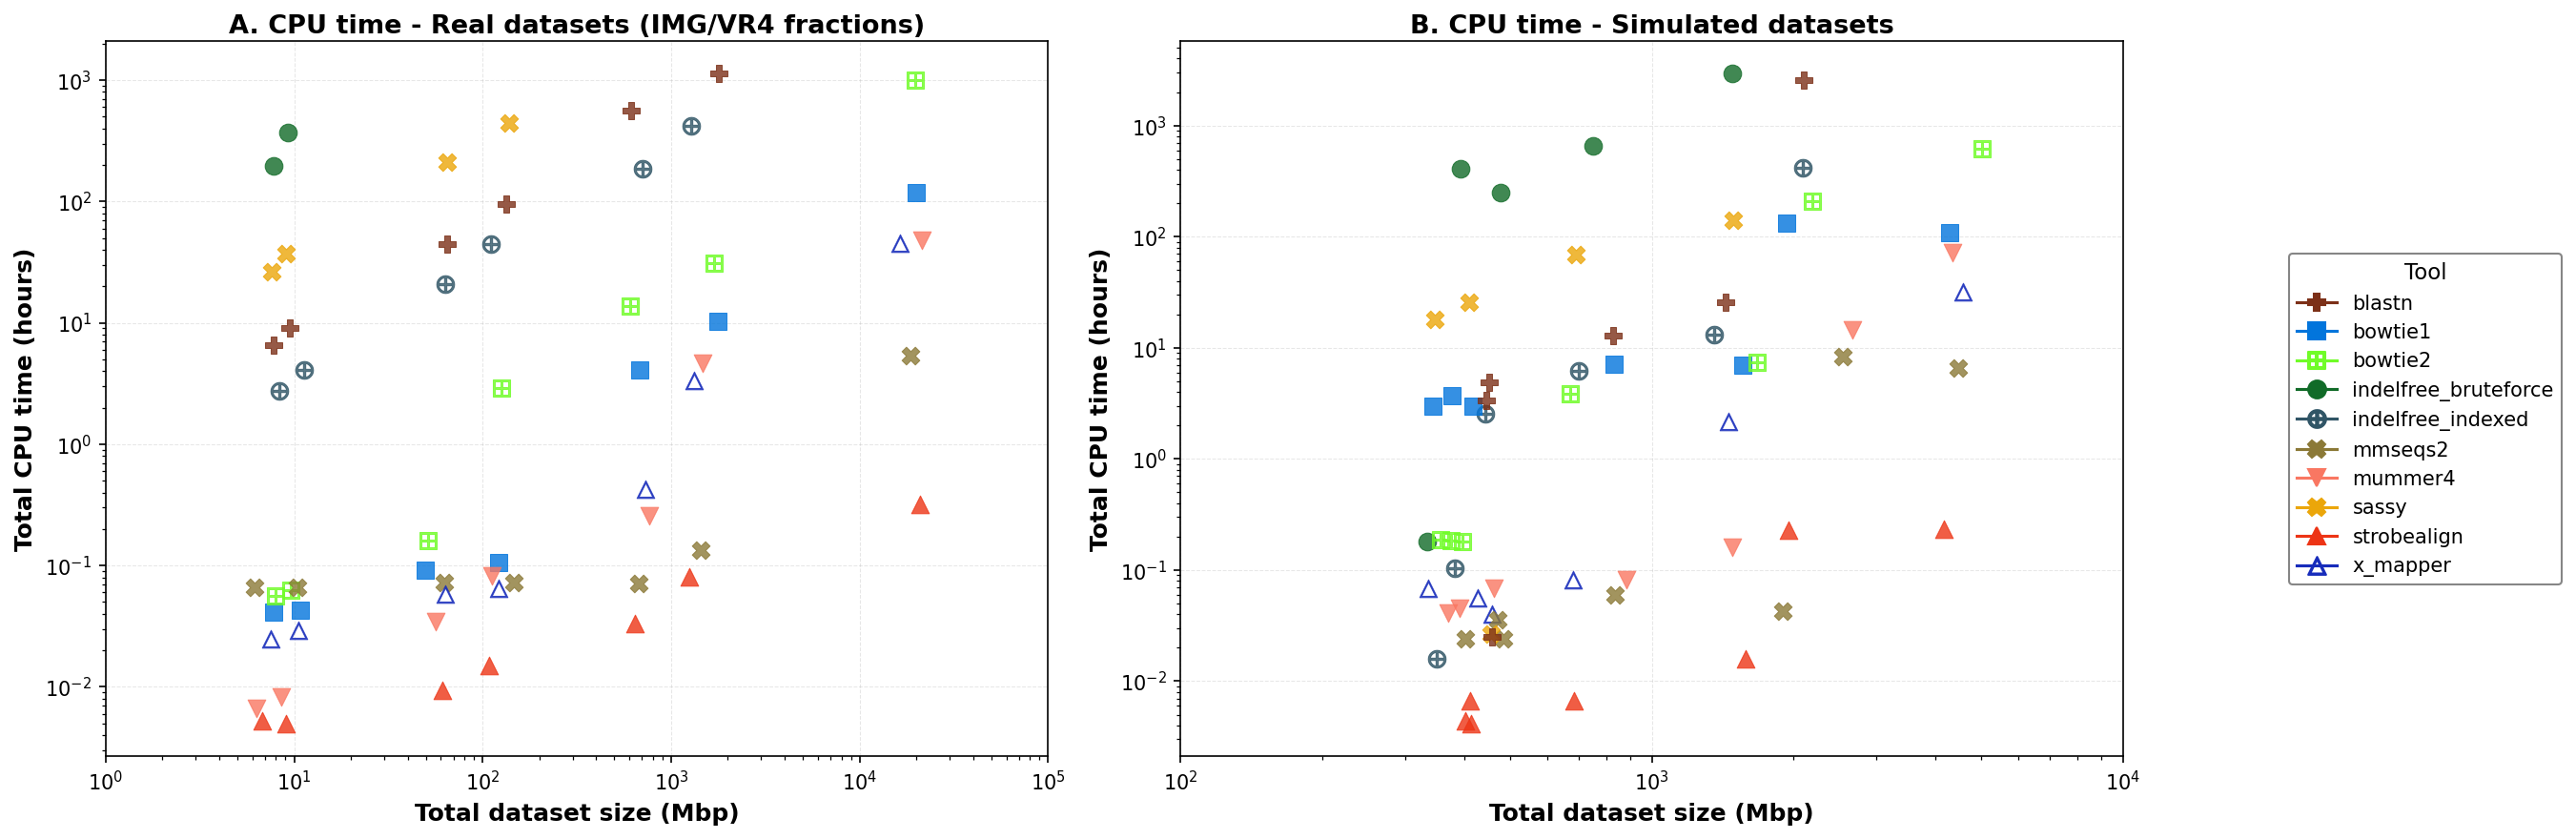

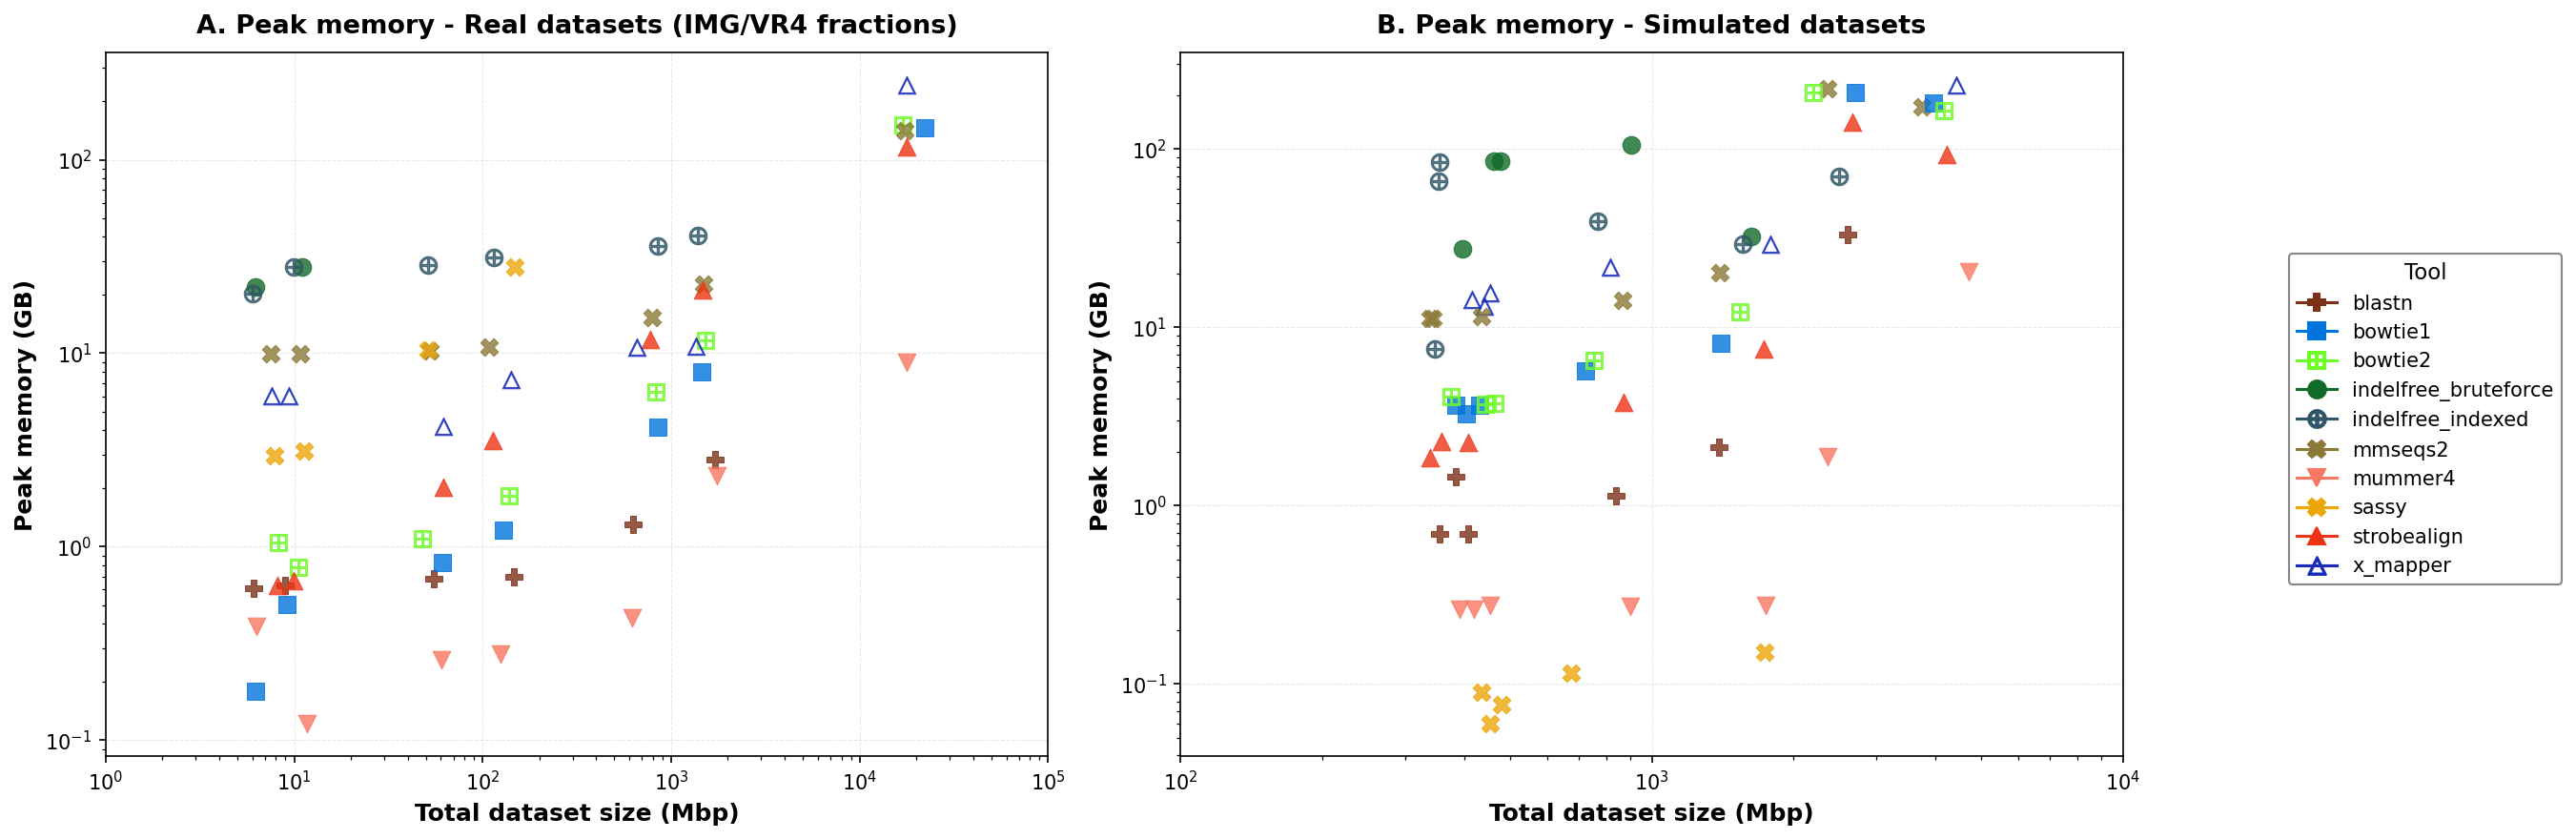

In [34]:
# Create separate figures for main text (CPU only) and supplementary (Memory only)
# Main text version excludes memory panels; supplementary holds memory panels.
import numpy as np
import matplotlib.ticker as mticker

# Get tool-specific colors and markers
tool_marker_map = {tool: styles['matplotlib_marker'] for tool, styles in tool_styles.items()}

# Fixed marker size (no longer encoding dataset size)
marker_size = 80
jitter_factor = 0.08  # 8% jitter on log scale

def jitter_log_x(x_vals, rng, jitter_factor):
    log_x = np.log10(x_vals)
    jitter = rng.uniform(-jitter_factor, jitter_factor, size=len(log_x))
    return 10 ** (log_x + jitter)

def apply_axis(ax, ticks):
    ax.set_xscale('log')
    ax.set_xlim(ticks[0], ticks[-1])
    ax.set_xticks(ticks)
    ax.xaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10))
    ax.xaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())

# Axis setup
real_x_raw = real_pd['total_size_Mbp'].to_numpy()
sim_x_raw = sim_pd['total_size_Mbp'].to_numpy()
sim_x_unique = np.sort(sim_pd['total_size_Mbp'].unique())
all_x_raw = np.concatenate([real_x_raw, sim_x_raw])

x_exp_max = int(np.ceil(np.log10(np.max(all_x_raw))))
real_x_exp_min = int(np.floor(np.log10(np.min(real_x_raw))))
sim_x_exp_min = 2  # start simulated panels at 10^2
sim_x_exp_max = 4  # cap simulated panels at 10^4

real_x_ticks = np.array([10 ** exp for exp in range(real_x_exp_min, x_exp_max + 1)], dtype=float)
sim_x_ticks = np.array([10 ** exp for exp in range(sim_x_exp_min, sim_x_exp_max + 1)], dtype=float)

# Deterministic RNGs for reproducible jitter
rng_cpu_real = np.random.default_rng(42)
rng_cpu_sim = np.random.default_rng(43)
rng_mem_real = np.random.default_rng(44)
rng_mem_sim = np.random.default_rng(45)

# Prepare memory-only subsets
real_pd_mem = real_pd[real_pd['Peak_Memory_Gb'].notna()].copy()
sim_pd_mem = sim_pd[sim_pd['Peak_Memory_Gb'].notna()].copy()

# Figure 1: CPU-only (Main text)
fig_cpu, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=150)
tools_plotted_cpu = set()

for tool in real_pd['base_tool'].unique():
    tool_data = real_pd[real_pd['base_tool'] == tool].copy()
    x_jittered = jitter_log_x(tool_data['total_size_Mbp'].to_numpy(), rng_cpu_real, jitter_factor)
    ax1.scatter(
        x_jittered,
        tool_data['CPU_Time_Hours'],
        c=[tool_colors[tool]],
        marker=tool_marker_map.get(tool, 'o'),
        s=marker_size,
        alpha=0.8,
        edgecolors=[tool_colors[tool]],
        linewidth=0.5,
        zorder=3
    )
    tools_plotted_cpu.add(tool)

apply_axis(ax1, real_x_ticks)
ax1.set_yscale('log')
ax1.set_xlabel('Total dataset size (Mbp)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total CPU time (hours)', fontsize=12, fontweight='bold')
ax1.set_title('A. CPU time - Real datasets (IMG/VR4 fractions)', fontsize=13, fontweight='bold', pad=4)
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

for tool in sim_pd['base_tool'].unique():
    tool_data = sim_pd[sim_pd['base_tool'] == tool].copy()
    x_jittered = jitter_log_x(tool_data['total_size_Mbp'].to_numpy(), rng_cpu_sim, jitter_factor)
    ax2.scatter(
        x_jittered,
        tool_data['CPU_Time_Hours'],
        c=[tool_colors[tool]],
        marker=tool_marker_map.get(tool, 'o'),
        s=marker_size,
        alpha=0.8,
        edgecolors=[tool_colors[tool]],
        linewidth=0.5,
        zorder=3
    )

apply_axis(ax2, sim_x_ticks)
ax2.set_yscale('log')
ax2.set_xlabel('Total dataset size (Mbp)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Total CPU time (hours)', fontsize=12, fontweight='bold')
ax2.set_title('B. CPU time - Simulated datasets', fontsize=13, fontweight='bold', pad=4)
ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

handles_cpu = []
labels_cpu = []
for tool in sorted(tools_plotted_cpu):
    handles_cpu.append(plt.Line2D([0], [0], marker=tool_marker_map.get(tool, 'o'), 
                                  color=tool_colors[tool], markerfacecolor=tool_colors[tool],
                                  markersize=9, markeredgewidth=1))
    labels_cpu.append(tool)

fig_cpu.legend(handles_cpu, labels_cpu, title='Tool', loc='center left', 
               bbox_to_anchor=(1.0, 0.5), fontsize=10, title_fontsize=11,
               framealpha=0.95, edgecolor='grey', ncol=1)
fig_cpu.tight_layout(rect=[0, 0, 0.95, 1])

fig_cpu.savefig(main_fig_dir / 'resource_usage_cpu_2panel.svg', dpi=300, bbox_inches='tight')
fig_cpu.savefig(main_fig_dir / 'resource_usage_cpu_2panel.png', dpi=300, bbox_inches='tight')

# Figure 2: Memory-only (Supplementary)
fig_mem, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 6), dpi=150)
tools_plotted_mem = set()

for tool in real_pd_mem['base_tool'].unique():
    tool_data = real_pd_mem[real_pd_mem['base_tool'] == tool].copy()
    x_jittered = jitter_log_x(tool_data['total_size_Mbp'].to_numpy(), rng_mem_real, jitter_factor)
    ax3.scatter(
        x_jittered,
        tool_data['Peak_Memory_Gb'],
        c=[tool_colors[tool]],
        marker=tool_marker_map.get(tool, 'o'),
        s=marker_size,
        alpha=0.8,
        edgecolors=[tool_colors[tool]],
        linewidth=0.5,
        zorder=3
    )
    tools_plotted_mem.add(tool)

apply_axis(ax3, real_x_ticks)
ax3.set_yscale('log')
ax3.set_xlabel('Total dataset size (Mbp)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Peak memory (GB)', fontsize=12, fontweight='bold')
ax3.set_title('A. Peak memory - Real datasets (IMG/VR4 fractions)', fontsize=13, fontweight='bold', pad=10)
ax3.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

for tool in sim_pd_mem['base_tool'].unique():
    tool_data = sim_pd_mem[sim_pd_mem['base_tool'] == tool].copy()
    x_jittered = jitter_log_x(tool_data['total_size_Mbp'].to_numpy(), rng_mem_sim, jitter_factor)
    ax4.scatter(
        x_jittered,
        tool_data['Peak_Memory_Gb'],
        c=[tool_colors[tool]],
        marker=tool_marker_map.get(tool, 'o'),
        s=marker_size,
        alpha=0.8,
        edgecolors=[tool_colors[tool]],
        linewidth=0.5,
        zorder=3
    )

apply_axis(ax4, sim_x_ticks)
ax4.set_yscale('log')
ax4.set_xlabel('Total dataset size (Mbp)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Peak memory (GB)', fontsize=12, fontweight='bold')
ax4.set_title('B. Peak memory - Simulated datasets', fontsize=13, fontweight='bold', pad=10)
ax4.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

handles_mem = []
labels_mem = []
for tool in sorted(tools_plotted_mem):
    handles_mem.append(plt.Line2D([0], [0], marker=tool_marker_map.get(tool, 'o'), 
                                  color=tool_colors[tool], markerfacecolor=tool_colors[tool],
                                  markersize=9, markeredgewidth=1))
    labels_mem.append(tool)

fig_mem.legend(handles_mem, labels_mem, title='Tool', loc='center left', 
               bbox_to_anchor=(1.0, 0.5), fontsize=10, title_fontsize=11,
               framealpha=0.95, edgecolor='grey', ncol=1)
fig_mem.tight_layout(rect=[0, 0, 0.95, 1])

fig_mem.savefig(supp_fig_dir / 'resource_usage_memory_2panel.svg', dpi=300, bbox_inches='tight')
fig_mem.savefig(supp_fig_dir / 'resource_usage_memory_2panel.png', dpi=300, bbox_inches='tight')

print(f"Saved main-text CPU figure to {main_fig_dir / 'resource_usage_cpu_2panel.svg'}")
print(f"Saved supplementary memory figure to {supp_fig_dir / 'resource_usage_memory_2panel.svg'}")
print('Real x ticks (Mbp):', ', '.join([f"1e{int(np.log10(x))}" for x in real_x_ticks]))
print('Sim x ticks (Mbp):', ', '.join([f"1e{int(np.log10(x))}" for x in sim_x_ticks]))
print('Simulated exact x-values (Mbp):', ', '.join([f"{x:.3f}" for x in sim_x_unique]))
plt.show()


## Part 4: Export Tables with Documentation


Export final tables for completed jobs to manuscript directories. Tables include all relevant metadata for reproducibility.


### Real Data Tables
- `resource_usage_real_data_completed_jobs.tsv`: All completed jobs on real (IMG/VR4) datasets
  - Columns: tool, fraction, BaseJobID, CPU_Time_Hours, Walltime_Hours, Peak_Memory_Gb, AllocCPUS, max_distance, note
  - Note: BLASTn fraction_1 CPU time is extrapolated (see note column)


### Simulated Data Tables
- `resource_usage_simulated_completed_jobs.tsv`: All completed jobs on simulated datasets
  - Columns: simulation, tool, search_space_size, num_spacers, num_contigs, CPU_Time_Hours, Walltime_Hours, Peak_Memory_Gb, AllocCPUS, max_distance


### Failed Jobs (Supplementary)
- `resource_usage_real_data_failed_jobs.tsv`: Jobs that timed out or failed
- `resource_usage_simulated_failed_jobs.tsv`: Failed simulated jobs


In [35]:
# Export real data completed jobs table
completed_jobs_export = completed_jobs.select([
    'tool', 'fraction', 'fraction_float', 'BaseJobID', 
    'CPU_Time_Hours', 'Walltime_Hours', 'Peak_Memory_Gb', 
    'AllocCPUS', 'max_distance',
]).sort(['tool', 'fraction_float'])


# Round numeric columns for readability
completed_jobs_export = completed_jobs_export.with_columns([
    pl.col('CPU_Time_Hours').round(2),
    pl.col('Walltime_Hours').round(2),
    pl.col('Peak_Memory_Gb').round(2)
])

# Export
completed_jobs_export.write_csv(supp_table_dir / 'resource_usage_real_data_completed_jobs.tsv', separator='\t')
completed_jobs_export.write_csv(main_table_dir / 'resource_usage_real_data_completed_jobs.tsv', separator='\t')


print(f"Exported real data completed jobs: {len(completed_jobs_export)} rows")
print(f"  Location: {supp_table_dir / 'resource_usage_real_data_completed_jobs.tsv'}")
print(completed_jobs_export)

# Export failed jobs if any
if len(failed_jobs) > 0:
    failed_jobs_export = failed_jobs.select([
        'tool', 'fraction', 'status', 'BaseJobID', 'Elapsed_Seconds', 'AllocCPUS'
    ]).with_columns([
        (pl.col('Elapsed_Seconds') / 3600).round(2).alias('Time_Hours')
    ]).drop('Elapsed_Seconds')
    
    failed_jobs_export.write_csv(supp_table_dir / 'resource_usage_real_data_failed_jobs.tsv', separator='\t')
    print(f"\nExported failed jobs: {len(failed_jobs_export)} rows")


Exported real data completed jobs: 67 rows
  Location: draft/supp/figures/tables/resource_usage_real_data_completed_jobs.tsv
shape: (67, 9)
┌──────────────────────┬──────────┬────────────────┬───────────┬────────────────┬────────────────┬────────────────┬───────────┬────────────────┐
│ tool                 ┆ fraction ┆ fraction_float ┆ BaseJobID ┆ CPU_Time_Hours ┆ Walltime_Hours ┆ Peak_Memory_Gb ┆ AllocCPUS ┆ max_distance   │
│ ---                  ┆ ---      ┆ ---            ┆ ---       ┆ ---            ┆ ---            ┆ ---            ┆ ---       ┆ ---            │
│ str                  ┆ str      ┆ f64            ┆ str       ┆ f64            ┆ f64            ┆ f64            ┆ i64       ┆ str            │
╞══════════════════════╪══════════╪════════════════╪═══════════╪════════════════╪════════════════╪════════════════╪═══════════╪════════════════╡
│ blastn               ┆ 0.0005   ┆ 0.0005         ┆ 20697879  ┆ 6.6            ┆ 0.55           ┆ 0.61           ┆ 38        ┆ perc_id

In [36]:
# Export simulated data completed jobs table
sim_jobs_export = processed_jobs_sim.select([
    'simulation', 'tool_name', 'BaseJobID', 'search_space_size',
    'num_spacers', 'num_contigs', 'total_spacer_Mbp', 'total_contig_Mbp',
    'CPU_Time_Hours', 'Walltime_Hours', 'Peak_Memory_Gb', 
    'AllocCPUS', 'max_distance_setting'
]).sort(['simulation', 'tool_name'])


# Round numeric columns
sim_jobs_export = sim_jobs_export.with_columns([
    pl.col('CPU_Time_Hours').round(2),
    pl.col('Walltime_Hours').round(2),
    pl.col('Peak_Memory_Gb').round(2),
    pl.col('total_spacer_Mbp').round(2),
    pl.col('total_contig_Mbp').round(2)
])


# Export
sim_jobs_export.write_csv(supp_table_dir / 'resource_usage_simulated_completed_jobs.tsv', separator='\t')
sim_jobs_export.write_csv(main_table_dir / 'resource_usage_simulated_completed_jobs.tsv', separator='\t')


print(f"Exported simulated data completed jobs: {len(sim_jobs_export)} rows")
print(f"  Location: {supp_table_dir / 'resource_usage_simulated_completed_jobs.tsv'}")
print(sim_jobs_export.head(10))


# Export failed jobs if any
if len(failed_jobs_sim) > 0:
    failed_jobs_sim_export = failed_jobs_sim.select([
        'simulation', 'tool_name', 'state_first', 'BaseJobID', 'Time_Hours', 'AllocCPUS'
    ])
    failed_jobs_sim_export.write_csv(supp_table_dir / 'resource_usage_simulated_failed_jobs.tsv', separator='\t')
    print(f"\nExported failed simulated jobs: {len(failed_jobs_sim_export)} rows")


Exported simulated data completed jobs: 70 rows
  Location: draft/supp/figures/tables/resource_usage_simulated_completed_jobs.tsv
shape: (10, 13)
┌────────────────────┬──────────────────────┬───────────┬───────────────────┬─────────────┬─────────────┬──────────────────┬──────────────────┬────────────────┬────────────────┬────────────────┬───────────┬──────────────────────┐
│ simulation         ┆ tool_name            ┆ BaseJobID ┆ search_space_size ┆ num_spacers ┆ num_contigs ┆ total_spacer_Mbp ┆ total_contig_Mbp ┆ CPU_Time_Hours ┆ Walltime_Hours ┆ Peak_Memory_Gb ┆ AllocCPUS ┆ max_distance_setting │
│ ---                ┆ ---                  ┆ ---       ┆ ---               ┆ ---         ┆ ---         ┆ ---              ┆ ---              ┆ ---            ┆ ---            ┆ ---            ┆ ---       ┆ ---                  │
│ str                ┆ str                  ┆ str       ┆ i64               ┆ i64         ┆ i64         ┆ f64              ┆ f64              ┆ f64            ┆ f64

## Summary and Notes for Manuscript


### Figure References
- **Main text**: `draft/main/figures/resource_usage/cpu_time_scaling_combined.svg` (panels A and B, no minimap2)

### Table References
- **Supplementary Table S8**: Resource usage for all completed jobs
  - Real data: `draft/supp/figures/tables/resource_usage_real_data_completed_jobs.tsv`
  - Simulated data: `draft/supp/figures/tables/resource_usage_simulated_completed_jobs.tsv`


### Important Notes for Manuscript Text
1. **BLASTn fraction_1 extrapolation**: CPU time was only tracked for 1,689,771 of 3,826,979 spacers (44%). Reported value is extrapolated by factor of 2.266 assuming linear scaling (validated on smaller fractions).

2. **Units**: 
   - CPU Time = Total CPU time already accounting for parallelization (SLURM TotalCPU)
   - Memory = Peak RSS (maximum resident set size)
   - Dataset size = Total nucleotides (spacers + contigs) in megabase pairs (Mbp)


3. **Tool selection**: Minimap2 excluded from main text figure due to poor performance in spacer-protospacer detection (see Performance_simulated_v2.ipynb and Performance_imgvr4_v2.ipynb). Included in supplementary for completeness.


4. **Hardware**: All jobs run on identical hardware (dual AMD EPYC 7543, 64 cores, 512 GB RAM) via SLURM with 64/38 threads allocated per job.
